## Сравнение качества моделей EPiC-Transformer, EPIC-GAN, iGAPT, MP-GAN по метрике $W_1$ для частицы с максимальным абсолютным значением импульса

GPU: T4

In [1]:
%pip install -q uproot
%pip install -q awkward-pandas


[notice] A new release of pip is available: 23.0.1 -> 26.1.1
[notice] To update, run: python3 -m pip install --upgrade pip

[notice] A new release of pip is available: 23.0.1 -> 26.1.1
[notice] To update, run: python3 -m pip install --upgrade pip


In [2]:
%pip install gdown==4.6.1

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 23.0.1 -> 26.1.1
[notice] To update, run: python3 -m pip install --upgrade pip


In [3]:
import torch
from torch import optim, nn
from torch.utils.data import TensorDataset, DataLoader
import os
import gdown
import math
import warnings
import uproot
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import numpy as np
from IPython.display import clear_output
from scipy import stats
from scipy.stats import wasserstein_distance
import random
from scipy.interpolate import interp1d
from scipy.integrate import simpson
from torch.nn.utils import clip_grad_norm_, weight_norm, spectral_norm
from copy import deepcopy
import torch.nn.functional as F
import warnings

In [4]:
warnings.filterwarnings("ignore")

In [5]:
N = 2112  # neutron PDG
P = 2212  # proton PDG
pion_masses = {211: 0.13957039, -211: 0.13957039, 111: 0.1349768}  # pions masses
pions = list(pion_masses)  # pions PDG
directions = ["x", "y", "z"]  # momenta components
nucleons = [N, P]
particles = nucleons + pions
label_to_num = {col: i for i, col in enumerate(pions)}  # ordinal encoding for pions PDG
num_to_label = {v: k for k, v in label_to_num.items()}  # ordinal decoding for pions PDG
feat_dim = 3  # generated data dimensionality
seeds = [0xF00D]  # , 0xC0FFEE, 0xDEAD]  # random seeds for experiments (use only one)
part_names = {
    111: r"$\pi_0$",
    -211: r"$\pi^-$",
    211: r"$\pi^+$",
    2112: r"$n$",
    2212: r"$p$",
}

In [6]:
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    torch.use_deterministic_algorithms(True, warn_only=True)


def get_masked_pt(p, pt_min=0.2, pt_max=None, eta_max=1.0):
    px, py, pz = p[..., 0], p[..., 1], p[..., 2]
    pt = torch.sqrt(px**2 + py**2)
    p_total = torch.sqrt(pt**2 + pz**2)
    eta = 0.5 * torch.log((p_total + pz) / (p_total - pz + 1e-10))
    mask = (pt > pt_min) & (torch.abs(eta) < eta_max)
    if pt_max is not None:
        mask = mask & (pt < pt_max)
    return mask, pt


def calc_pt_dist(data, pt_min=0.0, pt_max=1.2, eta_max=10.0):
    pt_list = []
    for event in data:
        mask, pt_event = get_masked_pt(event, pt_min, pt_max, eta_max)
        pt_sel = pt_event[mask]
        pt_list.append(pt_sel)
    return (
        torch.cat(pt_list)
        if pt_list
        else torch.tensor(
            [], device=data.device if isinstance(data, torch.Tensor) else data[0].device
        )
    )


def kl_divergence(real_kde, fake_kde, x, eps=1e-12):
    p = real_kde.evaluate(x)
    q = fake_kde.evaluate(x)
    return simpson(p * np.log((p + eps) / (q + eps)), x)


def w2_distance_1d(real, fake):
    real_sorted = np.sort(real)
    fake_sorted = np.sort(fake)
    if len(real_sorted) != len(fake_sorted):
        q = np.linspace(0, 1, min(len(real_sorted), len(fake_sorted)))
        real_quant = np.quantile(real_sorted, q)
        fake_quant = np.quantile(fake_sorted, q)
        return np.sqrt(np.mean((real_quant - fake_quant) ** 2))
    else:
        return np.sqrt(np.mean((real_sorted - fake_sorted) ** 2))


def calc_energy(px, py, pz, masses):
    return torch.sqrt(px**2 + py**2 + pz**2 + masses**2)


def calc_m_inv(row, mass_number=131):
    energy = np.sum(row["fParticles.fE"])
    px = np.sum(row["fParticles.fPx"])
    py = np.sum(row["fParticles.fPy"])
    pz = np.sum(row["fParticles.fPz"])
    M_inv = np.sqrt(np.maximum(0, energy**2 - (px**2 + py**2 + pz**2)))
    return M_inv / mass_number


def select_particles(row, target_col, mask_cols):
    feature_arr = np.array(row[target_col])
    mask_arr = np.zeros_like(feature_arr)
    for col in mask_cols:
        mask_arr += row[col]
    return feature_arr[mask_arr.astype(bool)]


def calc_pseudorapidity(px=None, py=None, pz=None, eps=1e-5):
    if isinstance(px, torch.Tensor):
        norm = torch.sqrt(px**2 + py**2 + pz**2)
        return 0.5 * torch.log(eps + (norm + pz) / (eps + norm - pz))
    else:
        norm = np.sqrt(px**2 + py**2 + pz**2)
        return 0.5 * np.log(eps + (norm + pz) / (eps + norm - pz))


def calc_pT(px, py):
    return np.sqrt(px**2 + py**2)


def calc_flows(px, py, weights=None):
    if isinstance(px, torch.Tensor):
        phi = torch.arctan2(py, px)
        n = len(phi)
        w = torch.ones(n) if weights is None else weights
        sum_w = torch.sum(w)
        v1 = np.sum(w * torch.cos(phi)) / sum_w
        v2 = np.sum(w * torch.cos(2 * phi)) / sum_w
        v3 = np.sum(w * torch.cos(3 * phi)) / sum_w
    else:
        phi = np.arctan2(py, px)
        n = len(phi)
        w = np.ones(n) if weights is None else weights
        sum_w = np.sum(w)
        v1 = np.sum(w * np.cos(phi)) / sum_w
        v2 = np.sum(w * np.cos(2 * phi)) / sum_w
        v3 = np.sum(w * np.cos(3 * phi)) / sum_w
    return v1, v2, v3


def get_nucleons_by_type(status, part_type="spectators"):
    if part_type == "spectators":
        return status == 0
    else:
        return status != 0


def get_part_spec(row, target_col, part_type="spectators"):
    nucleon_mask = np.array(row[N]) | np.array(row[P])
    nucleon_indices = np.where(nucleon_mask)[0]
    status = np.array(row["fParticles.fStatus"])[nucleon_indices]
    type_mask = get_nucleons_by_type(status, part_type)
    selected_indices = nucleon_indices[type_mask]
    return np.array(row[target_col])[selected_indices]


def get_final_moms(mom_x, mom_y, mom_z, energy, max_size):
    if mom_x.shape[0] >= max_size:
        mask = np.ones(max_size, dtype=float)
        mom_x = mom_x[:max_size]
        mom_y = mom_y[:max_size]
        mom_z = mom_z[:max_size]
        energy = energy[:max_size]
        mom_merged = np.vstack((mom_x, mom_y, mom_z, energy)).T
    else:
        mask = np.zeros(max_size)
        mask[: len(mom_x)] = 1.0
        zeros_x = np.zeros(max_size)
        zeros_x[: len(mom_x)] = mom_x
        zeros_y = np.zeros(max_size)
        zeros_y[: len(mom_y)] = mom_y
        zeros_z = np.zeros(max_size)
        zeros_z[: len(mom_z)] = mom_z
        zeros_e = np.zeros(max_size)
        zeros_e[: len(energy)] = energy
        mom_merged = np.vstack((zeros_x, zeros_y, zeros_z, zeros_e)).T
    return mom_merged, mask


def preprocess_urqmd(urqmd, max_size_t=80, max_size_c=250, return_cols=False):
    urqmd_new = pd.DataFrame()
    if "fB" in urqmd.columns:
        urqmd_new["B"] = urqmd["fB"]
    urqmd_new["m_inv"] = urqmd.apply(calc_m_inv, axis=1)
    for p in particles:
        urqmd[p] = urqmd["fParticles.fPdg"].apply(lambda x: np.array(x) == p)
    for d in directions:
        urqmd_new[f"mom_{d}"] = urqmd.apply(
            lambda x: select_particles(x, f"fParticles.fP{d}", nucleons), axis=1
        )
        urqmd_new[f"coord_{d}"] = urqmd.apply(
            lambda x: select_particles(x, f"fParticles.f{d.upper()}", nucleons), axis=1
        )
        urqmd_new[f"mom_part_{d}"] = urqmd.apply(
            lambda x: get_part_spec(x, f"fParticles.fP{d}", "participants"), axis=1
        )
        urqmd_new[f"coord_part_{d}"] = urqmd.apply(
            lambda x: get_part_spec(x, f"fParticles.f{d.upper()}", "participants"),
            axis=1,
        )
    urqmd_new["energy_part"] = urqmd.apply(
        lambda x: get_part_spec(x, "fParticles.fE", "participants"), axis=1
    )
    urqmd_new["energy"] = urqmd.apply(
        lambda x: select_particles(x, "fParticles.fE", nucleons), axis=1
    )
    urqmd_new["mom_norm"] = urqmd_new.apply(
        lambda x: np.sqrt(x["mom_x"] ** 2 + x["mom_y"] ** 2 + x["mom_z"] ** 2), axis=1
    )
    urqmd_new["pseudorapidity"] = urqmd_new.apply(
        lambda x: calc_pseudorapidity(px=x["mom_x"], py=x["mom_y"], pz=x["mom_z"]),
        axis=1,
    )
    urqmd_new["pseudorapidity_part"] = urqmd_new.apply(
        lambda x: calc_pseudorapidity(
            px=x["mom_part_x"], py=x["mom_part_y"], pz=x["mom_part_z"]
        ),
        axis=1,
    )
    urqmd_new["mom_T_part"] = urqmd_new.apply(
        lambda x: calc_pT(x["mom_part_x"], x["mom_part_y"]), axis=1
    )
    flows = urqmd_new.apply(
        lambda x: calc_flows(x["mom_part_x"], x["mom_part_y"]),
        axis=1,
        result_type="expand",
    )
    urqmd_new["v1"] = flows[0]
    urqmd_new["v2"] = flows[1]
    urqmd_new["v3"] = flows[2]
    urqmd_new["sum_mom"] = np.sqrt(
        urqmd_new["mom_x"].apply(np.sum) ** 2 + urqmd_new["mom_y"].apply(np.sum) ** 2
    )
    urqmd_new["rms_mom_T"] = np.sqrt(
        urqmd_new["mom_x"].apply(lambda arr: np.mean(arr**2))
        + urqmd_new["mom_y"].apply(lambda arr: np.mean(arr**2))
    )
    urqmd_new["n_p_ratio"] = urqmd.apply(lambda x: np.sum(x[N]) / np.sum(x[P]), axis=1)
    list_cols = [
        "mom_x",
        "mom_y",
        "mom_z",
        "mom_part_x",
        "mom_part_y",
        "mom_part_z",
        "mom_T_part",
        "coord_x",
        "coord_y",
        "coord_z",
        "coord_part_x",
        "coord_part_y",
        "coord_part_z",
        "energy_part",
        "mom_norm",
        "pseudorapidity_part",
        "pseudorapidity",
    ]
    percentiles = [0.5]
    for col in list_cols:
        try:
            urqmd_new[f"{col}_mean"] = urqmd_new[col].apply(np.mean)
            urqmd_new[f"{col}_var"] = urqmd_new[col].apply(np.var)
            urqmd_new[f"{col}_kurtosis"] = urqmd_new[col].apply(stats.kurtosis)
            urqmd_new[f"{col}_skew"] = urqmd_new[col].apply(stats.skew)
            for p in percentiles:
                urqmd_new[f"{col}_{p}_perc"] = urqmd_new[col].apply(
                    lambda x: np.percentile(x, p)
                )
        except:
            urqmd_new[f"{col}_mean"] = 0
            urqmd_new[f"{col}_var"] = 0
            urqmd_new[f"{col}_kurtosis"] = 0
            urqmd_new[f"{col}_skew"] = 0
            for p in percentiles:
                urqmd_new[f"{col}_{p}_perc"] = 0
    for col in ["psi1", "psi2", "mom_T", "phi"]:
        if col in urqmd_new.columns:
            urqmd_new.drop(columns=col, inplace=True)
    cond_cols = ["B", "v1", "v2", "v3"]
    urqmd[cond_cols] = urqmd_new[cond_cols]
    for p in particles:
        for d in directions:
            urqmd[f"{p}_mom_{d}"] = urqmd.apply(
                lambda x: select_particles(x, f"fParticles.fP{d}", [p]), axis=1
            )
        urqmd[f"{p}_energy"] = urqmd.apply(
            lambda x: select_particles(x, "fParticles.fE", [p]), axis=1
        )
    nucleons_cols = [f"{c}_moms" for c in nucleons if c != "nuclei"]
    nucleons_mask_cols = [f"{c}_mask" for c in nucleons if c != "nuclei"]
    df_rows = []
    for i, row in urqmd.iterrows():
        base_cond = {k: row[k] for k in cond_cols}
        for pion in pions:
            cond = base_cond.copy()
            cond["label"] = label_to_num[pion]
            cond["event"] = i
            mom_x = row[f"{pion}_mom_x"]
            mom_y = row[f"{pion}_mom_y"]
            mom_z = row[f"{pion}_mom_z"]
            energy = row[f"{pion}_energy"]
            for bc in nucleons:
                if bc == "nuclei":
                    continue
                baryon_mom_merged, baryon_mask = get_final_moms(
                    row[f"{bc}_mom_x"],
                    row[f"{bc}_mom_y"],
                    row[f"{bc}_mom_z"],
                    row[f"{bc}_energy"],
                    max_size_c,
                )
                cond[f"{bc}_moms"] = baryon_mom_merged
                cond[f"{bc}_mask"] = baryon_mask
            cond["nucleons_moms"] = np.concatenate(
                [cond["2112_moms"], cond["2212_moms"]], axis=0
            )
            cond["nucleons_mask"] = np.concatenate(
                [cond["2112_mask"], cond["2212_mask"]], axis=0
            )
            target_mom_merged, target_mask = get_final_moms(
                mom_x, mom_y, mom_z, energy, max_size_t
            )
            if target_mask.sum() == 0:
                continue
            cond["target_moms"] = target_mom_merged
            cond["target_mask"] = target_mask
            df_rows.append(cond)
    df = pd.DataFrame(df_rows)
    if return_cols:
        return df, cond_cols, ["nucleons_moms"], ["nucleons_mask"]
    return df


def get_part_spec_smash(df, eta_range=(0.5, 1.5), pt_threshold=0.2):
    df_copy = df.copy()
    status_list = []
    for _, row in df.iterrows():
        px = np.asarray(row["px"])
        py = np.asarray(row["py"])
        pz = np.asarray(row["pz"])
        pdg = np.asarray(row["pdgcode"])
        p = np.sqrt(px**2 + py**2 + pz**2)
        eta = 0.5 * np.log((p + pz) / (p - pz + 1e-12))
        pt = np.sqrt(px**2 + py**2)
        status = np.full(len(pdg), -1, dtype=np.int32)
        is_nucleon = np.isin(pdg, [2212, 2112])
        participant = ((eta > eta_range[0]) & (eta < eta_range[1])) | (
            pt > pt_threshold
        )
        status[is_nucleon] = np.where(participant[is_nucleon], 1, 0)
        status_list.append(status)
    df_copy["fParticles.fStatus"] = status_list
    return df_copy


def preprocess_smash(smash, max_size_t=80, max_size_c=250, return_cols=False):
    smash = get_part_spec_smash(smash)
    smash_new = pd.DataFrame()
    if "impact_b" in smash.columns:
        smash_new["B"] = smash["impact_b"]
    # urqmd_new["m_inv"] = urqmd.apply(calc_m_inv, axis=1)
    for p in particles:
        smash[p] = smash["pdgcode"].apply(lambda x: np.array(x) == p)
    for d in directions:
        smash_new[f"mom_{d}"] = smash.apply(
            lambda x: select_particles(x, f"p{d}", nucleons), axis=1
        )
        smash_new[f"coord_{d}"] = smash.apply(
            lambda x: select_particles(x, f"{d}", nucleons), axis=1
        )
        smash_new[f"mom_part_{d}"] = smash.apply(
            lambda x: get_part_spec(x, f"p{d}", "participants"), axis=1
        )
        smash_new[f"coord_part_{d}"] = smash.apply(
            lambda x: get_part_spec(x, f"{d}", "participants"),
            axis=1,
        )
    smash_new["energy_part"] = smash.apply(
        lambda x: get_part_spec(x, "p0", "participants"), axis=1
    )
    smash_new["energy"] = smash.apply(
        lambda x: select_particles(x, "p0", nucleons), axis=1
    )
    smash_new["mom_norm"] = smash_new.apply(
        lambda x: np.sqrt(x["mom_x"] ** 2 + x["mom_y"] ** 2 + x["mom_z"] ** 2), axis=1
    )
    smash_new["pseudorapidity"] = smash_new.apply(
        lambda x: calc_pseudorapidity(px=x["mom_x"], py=x["mom_y"], pz=x["mom_z"]),
        axis=1,
    )
    smash_new["pseudorapidity_part"] = smash_new.apply(
        lambda x: calc_pseudorapidity(
            px=x["mom_part_x"], py=x["mom_part_y"], pz=x["mom_part_z"]
        ),
        axis=1,
    )
    smash_new["mom_T_part"] = smash_new.apply(
        lambda x: calc_pT(x["mom_part_x"], x["mom_part_y"]), axis=1
    )
    flows = smash_new.apply(
        lambda x: calc_flows(x["mom_part_x"], x["mom_part_y"]),
        axis=1,
        result_type="expand",
    )
    smash_new["v1"] = flows[0]
    smash_new["v2"] = flows[1]
    smash_new["v3"] = flows[2]
    smash_new["sum_mom"] = np.sqrt(
        smash_new["mom_x"].apply(np.sum) ** 2 + smash_new["mom_y"].apply(np.sum) ** 2
    )
    smash_new["rms_mom_T"] = np.sqrt(
        smash_new["mom_x"].apply(lambda arr: np.mean(arr**2))
        + smash_new["mom_y"].apply(lambda arr: np.mean(arr**2))
    )
    smash_new["n_p_ratio"] = smash.apply(lambda x: np.sum(x[N]) / np.sum(x[P]), axis=1)
    list_cols = [
        "mom_x",
        "mom_y",
        "mom_z",
        "mom_part_x",
        "mom_part_y",
        "mom_part_z",
        "mom_T_part",
        "coord_x",
        "coord_y",
        "coord_z",
        "coord_part_x",
        "coord_part_y",
        "coord_part_z",
        "energy_part",
        "mom_norm",
        "pseudorapidity_part",
        "pseudorapidity",
    ]
    percentiles = [0.5]
    for col in list_cols:
        smash_new[f"{col}_mean"] = smash_new[col].apply(np.mean)
        smash_new[f"{col}_var"] = smash_new[col].apply(np.var)
        smash_new[f"{col}_kurtosis"] = smash_new[col].apply(stats.kurtosis)
        smash_new[f"{col}_skew"] = smash_new[col].apply(stats.skew)
        for p in percentiles:
            smash_new[f"{col}_{p}_perc"] = smash_new[col].apply(
                lambda x: np.percentile(x, p)
            )
    for col in ["psi1", "psi2", "mom_T", "phi"]:
        if col in smash_new.columns:
            smash_new.drop(columns=col, inplace=True)
    cond_cols = ["B", "v1", "v2", "v3"]
    smash[cond_cols] = smash_new[cond_cols]
    for p in particles:
        for d in directions:
            smash[f"{p}_mom_{d}"] = smash.apply(
                lambda x: select_particles(x, f"p{d}", [p]), axis=1
            )
        smash[f"{p}_energy"] = smash.apply(
            lambda x: select_particles(x, "p0", [p]), axis=1
        )
    nucleons_cols = [f"{c}_moms" for c in nucleons if c != "nuclei"]
    nucleons_mask_cols = [f"{c}_mask" for c in nucleons if c != "nuclei"]
    df_rows = []
    for i, row in smash.iterrows():
        base_cond = {k: row[k] for k in cond_cols}
        for pion in pions:
            cond = base_cond.copy()
            cond["label"] = label_to_num[pion]
            cond["event"] = i
            mom_x = row[f"{pion}_mom_x"]
            mom_y = row[f"{pion}_mom_y"]
            mom_z = row[f"{pion}_mom_z"]
            energy = row[f"{pion}_energy"]
            for bc in nucleons:
                if bc == "nuclei":
                    continue
                baryon_mom_merged, baryon_mask = get_final_moms(
                    row[f"{bc}_mom_x"],
                    row[f"{bc}_mom_y"],
                    row[f"{bc}_mom_z"],
                    row[f"{bc}_energy"],
                    max_size_c,
                )
                cond[f"{bc}_moms"] = baryon_mom_merged
                cond[f"{bc}_mask"] = baryon_mask
            cond["nucleons_moms"] = np.concatenate(
                [cond["2112_moms"], cond["2212_moms"]], axis=0
            )
            cond["nucleons_mask"] = np.concatenate(
                [cond["2112_mask"], cond["2212_mask"]], axis=0
            )
            target_mom_merged, target_mask = get_final_moms(
                mom_x, mom_y, mom_z, energy, max_size_t
            )
            if target_mask.sum() == 0:
                continue
            cond["target_moms"] = target_mom_merged
            cond["target_mask"] = target_mask
            df_rows.append(cond)
    df = pd.DataFrame(df_rows)
    if return_cols:
        return df, cond_cols, ["nucleons_moms"], ["nucleons_mask"]
    return df

In [7]:
def plot_losses(losses):
    clear_output()
    len_ = len(losses.keys())
    fig, ax = plt.subplots(nrows=1, ncols=len_, figsize=(3 * len_, 3))
    for j, k in enumerate(losses.keys()):
        ax[j].plot([i + 1 for i in range(len(losses[k]))], losses[k])
        ax[j].set_title(k)
    plt.tight_layout()
    plt.show()


def plot_kde(
    real, fake, dim_names, part_type, num=None, real_name="UrQMD", show_plots=True
):
    fig, axes = plt.subplots(2, 5, figsize=(25, 9))
    if num is not None:
        p_sq = real[..., 0] ** 2 + real[..., 1] ** 2 + real[..., 2] ** 2
        sorted_indices = torch.argsort(p_sq, dim=1, descending=True)
        kth_idx = sorted_indices[:, num]
        batch_idx = np.arange(real.shape[0])
        real = real[batch_idx, kth_idx]
        p_sq = fake[..., 0] ** 2 + fake[..., 1] ** 2 + fake[..., 2] ** 2
        sorted_indices = torch.argsort(p_sq, dim=1, descending=True)
        kth_idx = sorted_indices[:, num]
        batch_idx = np.arange(fake.shape[0])
        fake = fake[batch_idx, kth_idx]
    else:
        real = real.reshape(-1, real.shape[-1])
        fake = fake.reshape(-1, fake.shape[-1])
    real = real[~torch.all(real == 0.0, dim=1)]
    fake = fake[~torch.all(fake == 0.0, dim=1)]
    masses = torch.full_like(fake[..., -1], pion_masses[part_type])
    real_energy = real[..., -1]
    fake_energy = calc_energy(fake[..., 0], fake[..., 1], fake[..., 2], masses)
    real_eta = calc_pseudorapidity(real[..., 0], real[..., 1], real[..., 2])
    fake_eta = calc_pseudorapidity(fake[..., 0], fake[..., 1], fake[..., 2])
    metrics = {}
    for i in range(5):
        if i < 3:
            real_vals = real[:, i].numpy()
            fake_vals = fake[:, i].numpy()
            title_pre = f"{part_names[part_type]} ({dim_names[i]},"
            axes[0, i].set_xlabel(f"$p_{dim_names[i]}$")
            axes[1, i].set_xlabel(f"$p_{dim_names[i]}$")
        elif i == 3:
            real_vals = real_energy.numpy()
            fake_vals = fake_energy.numpy()
            title_pre = f"{part_names[part_type]} (" + r"$E$" + ", "
            axes[0, i].set_xlabel(r"$E$")
            axes[1, i].set_xlabel(r"$E$")
        else:
            real_vals = real_eta.numpy()
            fake_vals = fake_eta.numpy()
            title_pre = f"{part_names[part_type]} (" + r"$\eta$" + ", "
            axes[0, i].set_xlabel(r"$\eta$")
            axes[1, i].set_xlabel(r"$\eta$")
        kde_real = stats.gaussian_kde(real_vals, bw_method="scott")
        kde_fake = stats.gaussian_kde(fake_vals, bw_method="scott")
        x_points = np.linspace(
            min(real_vals.min(), fake_vals.min()),
            max(real_vals.max(), fake_vals.max()),
            1000,
        )
        pdf_real = kde_real(x_points)
        pdf_fake = kde_fake(x_points)
        kl = kl_divergence(kde_real, kde_fake, x_points)
        w1 = wasserstein_distance(real_vals, fake_vals)
        w2 = w2_distance_1d(real_vals, fake_vals)
        if i == 3:
            metrics["e_kl"] = kl
            metrics["e_w1"] = w1
        elif i > 3:
            metrics["eta_kl"] = kl
            metrics["eta_w1"] = w1
        axes[0, i].plot(x_points, pdf_real, label=real_name, color="tab:blue")
        axes[0, i].plot(x_points, pdf_fake, label="GAN", color="tab:red")
        axes[0, i].set_title(
            f'{title_pre} {"все частицы" if num is None else r"$p_{max}$" if num == 0 else num})\nKL={kl:.3f} W1={w1:.3f} W2={w2:.3f}'
        )
        axes[0, i].legend()
        axes[0, i].grid(True, alpha=0.3)
        axes[1, i].hist(
            real_vals, bins=50, alpha=0.5, color="tab:blue", label=real_name
        )
        axes[1, i].hist(
            fake_vals, bins=50, histtype="step", color="tab:red", label="GAN"
        )
        axes[1, i].set_title(
            f'{title_pre} {"все частицы" if num is None else r"$p_{max}$" if num == 0 else num})'
        )
        axes[1, i].legend()
        axes[1, i].grid(True, alpha=0.3)
    if show_plots:
        plt.tight_layout()
        plt.show()
    else:
        plt.close()
    return metrics


def plot_scatter(real, fake, real_name="UrQMD"):
    fig = plt.figure(figsize=(12, 5))
    ax1 = fig.add_subplot(121, projection="3d")
    real_flat = real.reshape(-1, real.shape[-1])
    fake_flat = fake.reshape(-1, fake.shape[-1])
    real_flat = real_flat[~torch.all(real_flat == 0.0, dim=1)]
    fake_flat = fake_flat[~torch.all(fake_flat == 0.0, dim=1)]
    ax1.scatter(
        real_flat[:, 0],
        real_flat[:, 1],
        real_flat[:, 2],
        alpha=0.6,
    )
    ax1.set_xlim(-2, 2)
    ax1.set_xlabel(r"$p_x$", fontsize=14, labelpad=10)
    ax1.set_ylim(-2, 2)
    ax1.set_ylabel(r"$p_y$", fontsize=14, labelpad=10)
    ax1.set_zlim(-2, 2)
    ax1.set_zlabel(r"$p_z$", fontsize=14, labelpad=10)
    ax1.set_title(real_name)
    ax2 = fig.add_subplot(122, projection="3d")
    ax2.scatter(
        fake_flat[:, 0],
        fake_flat[:, 1],
        fake_flat[:, 2],
        alpha=0.6,
        color="orange",
    )
    ax2.set_xlim(-2, 2)
    ax2.set_xlabel(r"$p_x$", fontsize=14, labelpad=10)
    ax2.set_ylim(-2, 2)
    ax2.set_ylabel(r"$p_y$", fontsize=14, labelpad=10)
    ax2.set_zlim(-2, 2)
    ax2.set_zlabel(r"$p_z$", fontsize=14, labelpad=10)
    ax2.set_title("GAN")
    plt.show()


def calc_vn_vs_pt(
    data, pt_min, pt_max, eta_max, nbins, n, min_particles=15, n_interp=200
):
    pt_all, phi_all = [], []
    for event in data:
        if isinstance(event, torch.Tensor):
            event = event.cpu().numpy()
        px = event[..., 0]
        py = event[..., 1]
        pz = event[..., 2]
        pt = np.sqrt(px**2 + py**2)
        p_total = np.sqrt(pt**2 + pz**2)
        eta = 0.5 * np.log((p_total + pz) / (p_total - pz + 1e-10))
        mask = (pt > pt_min) & (pt < pt_max) & (np.abs(eta) < eta_max)
        pt_all.extend(pt[mask])
        phi_all.extend(np.arctan2(py[mask], px[mask]))
    pt_all = np.array(pt_all)
    phi_all = np.array(phi_all)
    bin_edges = np.linspace(pt_min, pt_max, nbins + 1)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    vn_vals = np.full(nbins, np.nan)
    err_vals = np.full(nbins, np.nan)
    for i in range(nbins):
        mask_bin = (pt_all >= bin_edges[i]) & (pt_all < bin_edges[i + 1])
        count = np.sum(mask_bin)
        if count >= min_particles:
            cos_nphi = np.cos(n * phi_all[mask_bin])
            vn_vals[i] = np.mean(cos_nphi)
            err_vals[i] = np.std(cos_nphi) / np.sqrt(count)
    p_interp = np.linspace(pt_min, pt_max, n_interp)
    valid = ~np.isnan(vn_vals)
    if np.sum(valid) < 2:
        vn_interp = np.zeros_like(p_interp)
        err_interp = np.full_like(p_interp, 1.0)
        is_interp = np.ones_like(p_interp, dtype=bool)
        return p_interp, vn_interp, err_interp, is_interp
    f_vn = interp1d(
        bin_centers[valid],
        vn_vals[valid],
        kind="linear",
        fill_value="extrapolate",
        bounds_error=False,
    )
    f_err = interp1d(
        bin_centers[valid],
        err_vals[valid],
        kind="linear",
        fill_value="extrapolate",
        bounds_error=False,
    )
    vn_interp = f_vn(p_interp)
    err_interp = f_err(p_interp)
    bin_width = bin_edges[1] - bin_edges[0]
    is_interp = np.ones_like(p_interp, dtype=bool)
    for j, p_j in enumerate(p_interp):
        dist = np.min(np.abs(bin_centers[valid] - p_j))
        if dist <= bin_width * 0.6:
            is_interp[j] = False
    mean_err = np.nanmean(err_vals[valid])
    err_interp[is_interp] = np.maximum(err_interp[is_interp], 2.0 * mean_err)
    return p_interp, vn_interp, err_interp, is_interp


def plot_vn(
    real_data,
    fake_data,
    pt_min=0.0,
    pt_max=1.2,
    eta_max=10.0,
    nbins=10,
    pt_bins=50,
    min_particles=15,
    n_interp=200,
    real_name="UrQMD",
):
    metrics = {}
    fig, ax = plt.subplots(ncols=2, nrows=2, figsize=(16, 10))
    harmonics = [1, 2, 3]
    for idx, n in enumerate(harmonics):
        row = int(idx == 2)
        col = idx % 2
        real_p, real_vn, real_err, real_is_interp = calc_vn_vs_pt(
            real_data,
            pt_min,
            pt_max,
            eta_max,
            nbins,
            n,
            min_particles=min_particles,
            n_interp=n_interp,
        )
        fake_p, fake_vn, fake_err, fake_is_interp = calc_vn_vs_pt(
            fake_data,
            pt_min,
            pt_max,
            eta_max,
            nbins,
            n,
            min_particles=min_particles,
            n_interp=n_interp,
        )
        metrics[f"v{n}"] = np.nanmean((real_vn - fake_vn) ** 2)
        mask_real_meas = ~real_is_interp
        ax[row][col].plot(
            real_p[mask_real_meas],
            real_vn[mask_real_meas],
            color="C0",
            linewidth=2,
            label=f"{real_name} (измер.)",
        )
        ax[row][col].fill_between(
            real_p, real_vn - real_err, real_vn + real_err, alpha=0.2, color="C0"
        )
        mask_real_interp = real_is_interp
        if np.any(mask_real_interp):
            ax[row][col].plot(
                real_p[mask_real_interp],
                real_vn[mask_real_interp],
                "--",
                color="C0",
                linewidth=1,
                alpha=0.5,
                label=f"{real_name} (интерп.)" if idx == 0 else "",
            )
        mask_fake_meas = ~fake_is_interp
        ax[row][col].plot(
            fake_p[mask_fake_meas],
            fake_vn[mask_fake_meas],
            color="C3",
            linewidth=2,
            label="GAN (измер.)",
        )
        ax[row][col].fill_between(
            fake_p, fake_vn - fake_err, fake_vn + fake_err, alpha=0.2, color="C3"
        )
        mask_fake_interp = fake_is_interp
        if np.any(mask_fake_interp):
            ax[row][col].plot(
                fake_p[mask_fake_interp],
                fake_vn[mask_fake_interp],
                "--",
                color="C3",
                linewidth=1,
                alpha=0.5,
                label="GAN (интерп.)" if idx == 0 else "",
            )
        ax[row][col].set_xlabel(r"$p_T$ (GeV/c)", fontsize=12)
        ax[row][col].set_ylabel(f"$v_{{{n}}}$", fontsize=12)
        ax[row][col].legend(fontsize=9)
        ax[row][col].grid(alpha=0.3)
        ax[row][col].set_title(f"$v_{{{n}}}(p_T)$", fontsize=13)
    pt_real_all = calc_pt_dist(real_data)
    pt_fake_all = calc_pt_dist(fake_data)
    ax[1][1].hist(
        pt_real_all.numpy(),
        bins=pt_bins,
        density=True,
        alpha=0.5,
        label=real_name,
        color="C0",
    )
    ax[1][1].hist(
        pt_fake_all.numpy(),
        bins=pt_bins,
        density=True,
        alpha=0.5,
        label="GAN",
        color="C3",
    )
    ax[1][1].set_xlabel(r"$p_T$ (GeV/c)", fontsize=12)
    ax[1][1].set_ylabel("Нормированное число частиц", fontsize=12)
    ax[1][1].set_title("Распределение по $p_T$", fontsize=13)
    ax[1][1].legend()
    ax[1][1].grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    return metrics


def plot_pt(real, fake, mode="pt", real_name="UrQMD"):
    real_keys = [
        part_names[k] if k in part_names.keys() else str(k) for k in real.keys()
    ]
    real_values = [np.mean(v) for v in real.values()]
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.bar(real_keys, real_values, label=real_name, alpha=0.5)
    fake_keys = [
        part_names[k] if k in part_names.keys() else str(k) for k in fake.keys()
    ]
    fake_values = [np.mean(v) for v in fake.values()]
    bars = ax.bar(fake_keys, fake_values, label="GAN", alpha=0.5)
    real_values = np.array(real_values)
    fake_values = np.array(fake_values)
    ratios = [
        round(val, 2) for val in (np.abs(real_values - fake_values) / real_values * 100)
    ]
    str_ratios = [f"{val}%" for val in ratios]
    ax.bar_label(bars, labels=str_ratios, padding=3)
    ax.set_xlabel("particle type")
    ax.set_ylabel("value")
    ax.set_title(
        "Доля поперечного импульса в событии"
        if mode == "pt"
        else "Доля полной энергии в событии"
    )
    ax.grid(axis="y", linestyle="--", alpha=0.7)
    ax.legend()
    plt.show()
    return np.mean(ratios)

In [8]:
def lsgan_d_loss(d_real, d_fake):
    return 0.5 * (
        F.mse_loss(d_real, torch.ones_like(d_real))
        + F.mse_loss(d_fake, torch.zeros_like(d_fake))
    )


def lsgan_g_loss(d_fake):
    return 0.5 * F.mse_loss(d_fake, torch.ones_like(d_fake))

In [9]:
def generate_transformer(G, batch_size, n_points, cond, labels, device, threshold=0.5):
    G.eval()
    cond = cond.to(device)
    labels = labels.to(device)
    with torch.no_grad():
        impulses, mask_probs = G(labels, cond)
    mask = (mask_probs >= threshold).float()
    impulses = impulses * mask.unsqueeze(-1)
    return impulses.cpu()


def count_pt(particles):
    pt_parts = {}
    sum_pt = 0
    for k, v in particles.items():
        pt = torch.sum(torch.sqrt(v[..., 0] ** 2 + v[..., 1] ** 2))
        sum_pt += pt
        pt_parts[k] = pt
    pt_parts = {k: (v / sum_pt).item() for k, v in pt_parts.items()}
    return pt_parts


def count_e(particles):
    e_parts = {}
    sum_e = 0
    for k, v in particles.items():
        e = torch.sum(v[..., -1])
        sum_e += e
        e_parts[k] = e
    e_parts = {k: (v / sum_e).item() for k, v in e_parts.items()}
    return e_parts


def count_e_with_mass(particles):
    e_parts = {}
    sum_e = 0
    for k, v in particles.items():
        if k == "нуклоны":
            e = torch.sum(v[..., -1])
            sum_e += e
            e_parts[k] = e
        else:
            e = torch.sum(
                calc_energy(
                    v[..., 0],
                    v[..., 1],
                    v[..., 2],
                    torch.full_like(v[:, 0], pion_masses[k]),
                )
            )
            sum_e += e
            e_parts[k] = e
    e_parts = {k: (v / sum_e).item() for k, v in e_parts.items()}
    return e_parts


def get_dist_metrics(
    G,
    generate_func,
    n_points,
    test_mom,
    test_cond,
    test_label,
    test_mask,
    device,
    real_name="UrQMD",
    **kwargs
):
    metrics = {}
    for i in range(len(num_to_label)):
        metrics[num_to_label[i]] = {}
        mask = torch.tensor(test_label) == i
        if mask.sum() == 0:
            continue
        other_test = torch.tensor(test_mom, dtype=torch.float32)[mask]
        label_test = torch.tensor(test_label)[mask]
        mask_test = torch.tensor(test_mask, dtype=torch.float32)[mask]
        cond_test = torch.tensor(test_cond, dtype=torch.float32)[mask]
        generated_other = generate_func(
            G, mask.sum(), n_points, cond_test, label_test, device, **kwargs
        )
        m = plot_kde(
            other_test,
            generated_other,
            ["Px", "Py", "Pz"],
            num_to_label[i],
            real_name=real_name,
        )
        metrics[num_to_label[i]]["e_kl"] = m["e_kl"]
        metrics[num_to_label[i]]["e_w1"] = m["e_w1"]
        metrics[num_to_label[i]]["eta_kl"] = m["eta_kl"]
        metrics[num_to_label[i]]["eta_w1"] = m["eta_w1"]
        m_0 = plot_kde(
            other_test,
            generated_other,
            ["Px", "Py", "Pz"],
            num_to_label[i],
            num=0,
            real_name=real_name,
            show_plots=False,
        )
        metrics[num_to_label[i]]["e_kl_0"] = m_0["e_kl"]
        metrics[num_to_label[i]]["e_w1_0"] = m_0["e_w1"]
        metrics[num_to_label[i]]["eta_kl_0"] = m_0["eta_kl"]
        metrics[num_to_label[i]]["eta_w1_0"] = m_0["eta_w1"]
        plot_kde(
            other_test,
            generated_other,
            ["Px", "Py", "Pz"],
            num_to_label[i],
            num=1,
            real_name=real_name,
            show_plots=False,
        )
        plot_kde(
            other_test,
            generated_other,
            ["Px", "Py", "Pz"],
            num_to_label[i],
            num=2,
            real_name=real_name,
            show_plots=False,
        )
        plot_scatter(other_test, generated_other, real_name=real_name)
        vn_metrics = plot_vn(other_test, generated_other, real_name=real_name)
        for k, v in vn_metrics.items():
            metrics[num_to_label[i]][k] = v
    return metrics


def get_energy_metrics(
    G,
    generate_func,
    n_points,
    test_mom,
    test_nucl,
    test_nucl_mask,
    test_event,
    test_cond,
    test_label,
    test_mask,
    device,
    real_name="UrQMD",
    **kwargs
):
    all_real_pt = {}
    all_fake_pt = {}
    all_real_e = {}
    all_fake_e = {}
    for i in np.unique(test_event):
        mask = torch.tensor(test_event) == i
        if mask.sum() == 0:
            continue
        other_test = torch.tensor(test_mom, dtype=torch.float32)[mask]
        real = {}
        fake = {}
        real["нуклоны"] = torch.tensor(test_nucl, dtype=torch.float32)[mask][0]
        fake["нуклоны"] = torch.tensor(test_nucl, dtype=torch.float32)[mask][0]
        label_test = torch.tensor(test_label)[mask]
        mask_test = torch.tensor(test_mask, dtype=torch.float32)[mask]
        cond_test = torch.tensor(test_cond, dtype=torch.float32)[mask]
        generated_other = generate_func(
            G, mask.sum(), n_points, cond_test, label_test, device, **kwargs
        )
        for i in range(len(label_test)):
            real[num_to_label[label_test[i].item()]] = other_test[i]
            fake[num_to_label[label_test[i].item()]] = generated_other[i]
        real_pt = count_pt(real)
        fake_pt = count_pt(fake)
        real_e = count_e(real)
        fake_e = count_e_with_mass(fake)
        for k in real_pt.keys():
            if k in all_real_pt:
                all_real_pt[k].append(real_pt[k])
                all_fake_pt[k].append(fake_pt[k])
                all_real_e[k].append(real_e[k])
                all_fake_e[k].append(fake_e[k])
            else:
                all_real_pt[k] = [real_pt[k]]
                all_fake_pt[k] = [fake_pt[k]]
                all_real_e[k] = [real_e[k]]
                all_fake_e[k] = [fake_e[k]]
    metrics = {}
    pt_ = plot_pt(all_real_pt, all_fake_pt, real_name=real_name)
    e_ = plot_pt(all_real_e, all_fake_e, mode="energy", real_name=real_name)
    for p in pions:
        metrics[p] = {}
        metrics[p]["pt"] = pt_
        metrics[p]["e"] = e_
    return metrics

In [10]:
def update_average(model_tgt, model_src, beta):
    with torch.no_grad():
        params_src = dict(model_src.named_parameters())
        params_tgt = dict(model_tgt.named_parameters())
        for k in params_src.keys():
            params_tgt[k].data.copy_(
                torch.lerp(params_tgt[k].data, params_src[k].data, 1.0 - beta)
            )

In [11]:
device = "cuda" if torch.cuda.is_available() else "cpu"

In [12]:
def get_flow_metric(G, batch, device):
    G.eval()
    with torch.no_grad():
        real_impulses, cond, labels, mask = batch
        real_impulses = real_impulses[..., :3].to(device)
        cond = cond.to(device)
        labels = labels.to(device)
        mask = mask.to(device)
        bs = real_impulses.size(0)

        fake_impulses, fake_mask = G(labels, cond)
        fake_masked = fake_impulses * fake_mask.unsqueeze(-1)

        real_np = real_impulses.cpu().numpy()
        fake_np = fake_masked.cpu().numpy()
        mask_np = mask.cpu().numpy()
        fake_mask_np = fake_mask.cpu().numpy() > 0.5

        total_loss = 0.0
        count = 0
        for b in range(bs):
            ra = real_np[b, mask_np[b].astype(bool)]
            fa = fake_np[b, fake_mask_np[b]]
            if len(ra) < 2 or len(fa) < 2:
                continue
            v1r, v2r, v3r = calc_flows(ra[:, 0], ra[:, 1])
            v1f, v2f, v3f = calc_flows(fa[:, 0], fa[:, 1])
            total_loss += (v1r - v1f) ** 2 + (v2r - v2f) ** 2 + (v3r - v3f) ** 2
            count += 1
        return total_loss / count if count > 0 else float("inf")

In [13]:
def train_epoch(
    G,
    D,
    dataloader,
    opt_G,
    opt_D,
    device,
    lambda_flow=0.05,
    d_iters=1,
    lambda_gp=1,
    use_shadow=False,
    G_shadow=None,
    ema_beta=0.999,
    clip_val=1.0,
):
    G.train()
    D.train()
    epoch_d_loss = 0.0
    epoch_g_loss = 0.0
    epoch_flow_loss = 0.0
    num_batches = 0

    for real_impulses, cond, labels, mask in dataloader:
        real_impulses = real_impulses[..., :3].to(device)
        cond = cond.to(device)
        labels = labels.to(device)
        mask = mask.to(device)
        bs = real_impulses.size(0)
        opt_D.zero_grad()
        d_real = D(real_impulses, labels, cond, mask)
        with torch.no_grad():
            fake_impulses, fake_mask = G(labels, cond)
        fake_masked = fake_impulses * fake_mask.unsqueeze(-1)
        d_fake = D(fake_masked, labels, cond, fake_mask)
        d_loss = lsgan_d_loss(d_real, d_fake)
        d_loss.backward()
        nn.utils.clip_grad_norm_(D.parameters(), clip_val)
        opt_D.step()
        opt_G.zero_grad()
        fake_impulses, fake_mask = G(labels, cond)
        fake_masked = fake_impulses * fake_mask.unsqueeze(-1)
        d_fake = D(fake_masked, labels, cond, fake_mask)
        g_loss = lsgan_g_loss(d_fake)
        flow_loss = torch.tensor(0.0, device=device)
        if lambda_flow > 0:
            real_px = real_impulses[..., 0] * mask
            real_py = real_impulses[..., 1] * mask
            sum_w_real = mask.sum(dim=1, keepdim=True) + 1e-8
            phi_real = torch.atan2(real_py, real_px)
            v1r = (mask * torch.cos(phi_real)).sum(dim=1) / sum_w_real.squeeze()
            v2r = (mask * torch.cos(2 * phi_real)).sum(dim=1) / sum_w_real.squeeze()
            v3r = (mask * torch.cos(3 * phi_real)).sum(dim=1) / sum_w_real.squeeze()
            fake_px = fake_impulses[..., 0] * fake_mask
            fake_py = fake_impulses[..., 1] * fake_mask
            sum_w_fake = fake_mask.sum(dim=1, keepdim=True) + 1e-8
            phi_fake = torch.atan2(fake_py, fake_px)
            v1f = (fake_mask * torch.cos(phi_fake)).sum(dim=1) / sum_w_fake.squeeze()
            v2f = (fake_mask * torch.cos(2 * phi_fake)).sum(
                dim=1
            ) / sum_w_fake.squeeze()
            v3f = (fake_mask * torch.cos(3 * phi_fake)).sum(
                dim=1
            ) / sum_w_fake.squeeze()
            flow_loss = ((v1r - v1f) ** 2 + (v2r - v2f) ** 2 + (v3r - v3f) ** 2).mean()
        mask_loss = F.binary_cross_entropy(fake_mask, mask)
        real_len = mask.sum(dim=1)
        fake_len = fake_mask.sum(dim=1)
        len_loss = F.mse_loss(fake_len, real_len)
        total_g_loss = g_loss + lambda_flow * flow_loss + mask_loss + len_loss
        total_g_loss.backward()
        nn.utils.clip_grad_norm_(G.parameters(), clip_val)
        opt_G.step()
        epoch_d_loss += d_loss.item()
        epoch_g_loss += g_loss.item()
        epoch_flow_loss += flow_loss.item()
        num_batches += 1
        if use_shadow and G_shadow is not None:
            update_average(G_shadow, G, ema_beta)
    return {
        "d_loss": epoch_d_loss / num_batches,
        "g_loss": epoch_g_loss / num_batches,
        "flow_loss": epoch_flow_loss / num_batches,
    }


def get_metrics(
    G,
    test_df,
    cond_cols,
    nucl_cols,
    nucl_mask_cols,
    meson_max,
    device,
    final_metrics,
    real_name="UrQMD",
):
    test_mom = torch.tensor(list(test_df["target_moms"].values), dtype=torch.float32)
    test_cond = torch.tensor(test_df[cond_cols].values, dtype=torch.float32)
    test_label = torch.tensor(test_df["label"].values)
    test_mask = torch.tensor(list(test_df["target_mask"].values), dtype=torch.float32)
    test_nucl = torch.tensor(list(test_df[nucl_cols[0]].values), dtype=torch.float32)
    test_nucl_mask = torch.tensor(
        list(test_df[nucl_mask_cols[0]].values), dtype=torch.float32
    )
    test_event = torch.tensor(test_df["event"].values)
    dist_metrics = get_dist_metrics(
        G,
        generate_func=generate_transformer,
        n_points=meson_max,
        test_mom=test_mom,
        test_cond=test_cond,
        test_label=test_label,
        test_mask=test_mask,
        device=device,
        real_name=real_name,
    )
    energy_metrics = get_energy_metrics(
        G,
        generate_func=generate_transformer,
        n_points=meson_max,
        test_mom=test_mom,
        test_nucl=test_nucl,
        test_nucl_mask=test_nucl_mask,
        test_event=test_event,
        test_cond=test_cond,
        test_label=test_label,
        test_mask=test_mask,
        device=device,
        real_name=real_name,
    )
    combined = {}
    for pid in dist_metrics:
        combined[pid] = {**dist_metrics[pid], **energy_metrics.get(pid, {})}
    for pid in energy_metrics:
        if pid not in combined:
            combined[pid] = energy_metrics[pid]
    final_metrics.clear()
    final_metrics.update(combined)
    return dist_metrics, energy_metrics

In [14]:
class GaussianMixtureLatent(nn.Module):
    def __init__(self, n_modes, dim, max_len):
        super().__init__()
        self.d = dim
        self.n_modes = n_modes
        self.max_len = max_len

    def forward(self, batch_size):
        pass


class LearnableMixtureLatent(GaussianMixtureLatent):
    def __init__(self, n_modes, dim, max_len=None):
        super().__init__(n_modes=n_modes, dim=dim, max_len=max_len)
        self.mu = nn.Parameter(torch.randn(n_modes, dim) * 0.02)
        self.log_sigma = nn.Parameter(torch.randn(n_modes, dim) * 0.02)
        self.register_buffer("weights", torch.ones(n_modes) / n_modes)

    def get_sigma(self):
        return torch.exp(torch.tanh(self.log_sigma))

    def forward(self, batch_size):
        sigma = self.get_sigma()
        comp_idx = torch.multinomial(self.weights, batch_size, replacement=True)
        if self.max_len is not None:
            z = torch.randn(batch_size, self.max_len, self.d, device=self.mu.device)
            mu_g = self.mu[comp_idx]
            sigma_g = sigma[comp_idx]
            return mu_g.unsqueeze(1) + sigma_g.unsqueeze(1) * z
        z = torch.randn(batch_size, self.d, device=self.mu.device)
        mu_g = self.mu[comp_idx]
        sigma_g = sigma[comp_idx]
        return mu_g + sigma_g * z


class FixedMixtureLatent(GaussianMixtureLatent):
    def __init__(self, n_modes, dim, param_scale=0.5, max_len=None):
        super().__init__(n_modes=n_modes, dim=dim, max_len=max_len)
        self.register_buffer("mu", param_scale * torch.randn(n_modes, dim))
        self.register_buffer("sigma", param_scale * torch.rand(n_modes, dim))
        self.register_buffer("weights", torch.ones(n_modes) / n_modes)

    def forward(self, batch_size):
        comp_idx = torch.multinomial(self.weights, batch_size, replacement=True)
        if self.max_len is not None:
            z = torch.randn(batch_size, self.max_len, self.d, device=self.mu.device)
            mu_g = self.mu[comp_idx]
            sigma_g = self.sigma[comp_idx]
            return mu_g.unsqueeze(1) + sigma_g.unsqueeze(1) * z
        z = torch.randn(batch_size, self.d, device=self.mu.device)
        mu_g = self.mu[comp_idx]
        sigma_g = self.sigma[comp_idx]
        return mu_g + sigma_g * z


class StandardNormalLatent(GaussianMixtureLatent):
    def __init__(self, dim, max_len=None):
        super().__init__(n_modes=1, dim=dim, max_len=max_len)
        self.register_buffer("weights", torch.ones(1))

    def forward(self, batch_size):
        if self.max_len is not None:
            z = torch.randn(
                batch_size, self.max_len, self.d, device=self.weights.device
            )
        else:
            z = torch.randn(batch_size, self.d, device=self.weights.device)
        return z

In [15]:
class TransformerBlock(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, neg_slope=0.2, use_weight_norm=False):
        super().__init__()
        self.self_attn = nn.MultiheadAttention(d_model, n_heads, batch_first=True)
        self.cross_attn = nn.MultiheadAttention(d_model, n_heads, batch_first=True)
        self.ff = nn.Sequential(
            (
                weight_norm(nn.Linear(d_model, d_ff))
                if use_weight_norm
                else nn.Linear(d_model, d_ff)
            ),
            nn.LeakyReLU(neg_slope),
            (
                weight_norm(nn.Linear(d_ff, d_model))
                if use_weight_norm
                else nn.Linear(d_ff, d_model)
            ),
        )

    def forward(self, x_local, x_global, mask=None):
        residual = x_local
        key_padding_mask = None if mask is None else (mask == 0)
        attn_out, _ = self.self_attn(
            x_local, x_local, x_local, key_padding_mask=key_padding_mask
        )
        x_local = residual + attn_out
        residual = x_local
        if x_global.dim() == 2:
            x_global_expanded = x_global.unsqueeze(1)
        else:
            x_global_expanded = x_global
        attn_out, _ = self.cross_attn(x_local, x_global_expanded, x_global_expanded)
        x_local = residual + attn_out
        residual = x_local
        x_local = residual + self.ff(x_local)
        return x_local


class Pion_Gan_Generator(nn.Module):
    def __init__(
        self,
        latent_global=128,
        latent_local=16,
        num_labels=5,
        extern_cond_d=6,
        feats=3,
        d_model=256,
        n_heads=8,
        d_ff=512,
        max_len=80,
        n_layers=6,
        n_modes=3,
        neg_slope=0.2,
        use_weight_norm=False,
        use_learnable_noise=True,
    ):
        super().__init__()
        self.latent_local = latent_local
        self.feats = feats
        self.extern_cond_d = extern_cond_d
        self.emb = nn.Embedding(num_labels, d_model)
        if extern_cond_d is None:
            self.cond_proj = (
                weight_norm(nn.Linear(2 * d_model, d_model))
                if use_weight_norm
                else nn.Linear(2 * d_model, d_model)
            )
        else:
            self.cond_proj = (
                weight_norm(nn.Linear(extern_cond_d + 2 * d_model, d_model))
                if use_weight_norm
                else nn.Linear(extern_cond_d + 2 * d_model, d_model)
            )
        self.global_proj = (
            weight_norm(nn.Linear(latent_global, d_model))
            if use_weight_norm
            else nn.Linear(latent_global, d_model)
        )
        self.local_proj = (
            weight_norm(nn.Linear(latent_local, d_model))
            if use_weight_norm
            else nn.Linear(latent_local, d_model)
        )
        self.blocks = nn.ModuleList(
            [
                TransformerBlock(d_model, n_heads, d_ff, neg_slope)
                for _ in range(n_layers)
            ]
        )
        self.out_impulse = (
            weight_norm(nn.Linear(d_model, feats))
            if use_weight_norm
            else nn.Linear(d_model, feats)
        )
        self.out_mask = (
            weight_norm(nn.Linear(d_model, 1))
            if use_weight_norm
            else nn.Linear(d_model, 1)
        )
        if not use_weight_norm:
            self.apply(self._init_weights)
        self.local_sampler = (
            LearnableMixtureLatent(n_modes, latent_local, max_len)
            if use_learnable_noise
            else StandardNormalLatent(latent_local, max_len=max_len)
        )
        self.global_sampler = (
            LearnableMixtureLatent(n_modes, latent_global)
            if use_learnable_noise
            else StandardNormalLatent(latent_global)
        )

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            nn.init.xavier_uniform_(module.weight)
            if module.bias is not None:
                nn.init.constant_(module.bias, 0)
        elif isinstance(module, nn.Embedding):
            nn.init.normal_(module.weight, mean=0, std=0.02)

    def forward(self, labels, cond=None):
        batch_size = labels.size(0)
        z_local = self.local_sampler(batch_size)
        z_global = self.global_sampler(batch_size)
        labels_emb = self.emb(labels)
        x_global = self.global_proj(z_global)
        if self.extern_cond_d is not None:
            context = torch.cat([x_global, labels_emb, cond], dim=-1)
        else:
            context = torch.cat([x_global, labels_emb], dim=-1)
        context = self.cond_proj(context.unsqueeze(1))
        slots = self.local_proj(z_local)
        for block in self.blocks:
            slots = block(slots, context, mask=None)
        impulses = self.out_impulse(slots)
        mask_logits = self.out_mask(slots).squeeze(-1)
        mask = torch.sigmoid(mask_logits)
        return impulses, mask


class Pion_Gan_Discriminator(nn.Module):
    def __init__(
        self,
        feats=3,
        num_labels=5,
        d_model=256,
        extern_cond_d=6,
        n_heads=8,
        d_ff=512,
        n_layers=6,
        neg_slope=0.2,
        use_weight_norm=False,
    ):
        super().__init__()
        self.d_model = d_model
        self.extern_cond_d = extern_cond_d
        self.input_proj = (
            weight_norm(nn.Linear(feats, d_model))
            if use_weight_norm
            else nn.Linear(feats, d_model)
        )
        self.emb = nn.Embedding(num_labels, d_model)
        self.blocks = nn.ModuleList(
            [
                TransformerBlock(d_model, n_heads, d_ff, neg_slope)
                for _ in range(n_layers)
            ]
        )
        if extern_cond_d is not None:
            self.cond_proj = (
                weight_norm(nn.Linear(extern_cond_d + 2 * d_model, d_model))
                if use_weight_norm
                else nn.Linear(extern_cond_d + 2 * d_model, d_model)
            )
        else:
            self.cond_proj = (
                weight_norm(nn.Linear(2 * d_model, d_model))
                if use_weight_norm
                else nn.Linear(2 * d_model, d_model)
            )
        self.global_proj = nn.Sequential(
            (
                weight_norm(nn.Linear(3 * d_model, d_model))
                if use_weight_norm
                else nn.Linear(3 * d_model, d_model)
            ),
            nn.LeakyReLU(neg_slope),
            (
                weight_norm(nn.Linear(d_model, 1))
                if use_weight_norm
                else nn.Linear(d_model, 1)
            ),
        )
        if not use_weight_norm:
            self.apply(self._init_weights)

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            nn.init.xavier_uniform_(module.weight)
            if module.bias is not None:
                nn.init.constant_(module.bias, 0)
        elif isinstance(module, nn.Embedding):
            nn.init.normal_(module.weight, mean=0, std=0.02)

    def forward(self, x, labels, cond=None, mask=None):
        B, N, _ = x.shape
        x_local = self.input_proj(x)
        label_emb = self.emb(labels).unsqueeze(1)
        if mask is not None:
            #    masked = x_local * mask.unsqueeze(-1)
            x_global = x_local.sum(dim=1) / (1e-8 + mask.sum(dim=1, keepdim=True))
        else:
            x_global = x_local.mean(dim=1)
        if self.extern_cond_d is not None:
            x_global = torch.cat([x_global, label_emb.squeeze(1), cond], dim=-1)
        else:
            x_global = torch.cat([x_global, label_emb.squeeze(1)], dim=-1)
        x_global = self.cond_proj(x_global)
        for block in self.blocks:
            x_local = block(x_local, x_global, mask)
        if mask is not None:
            masked = x_local * mask.unsqueeze(-1)
            final_mean = masked.sum(dim=1) / (1e-8 + mask.sum(dim=1, keepdim=True))
            final_sum = masked.sum(dim=1)
        else:
            final_mean = x_local.mean(dim=1)
            final_sum = x_local.sum(dim=1)
        final_feat = torch.cat([final_mean, final_sum, x_global], dim=-1)
        out = self.global_proj(final_feat).squeeze(-1)
        return out

In [16]:
latent_dim = 32
latent_local_dim = 32
hid_dim = 64
num_classes = 3
feat_dim = 3
num_layers_gen = 5
num_layers_disc = 5
n_heads = 8
n_modes = 3
batch_size = 128

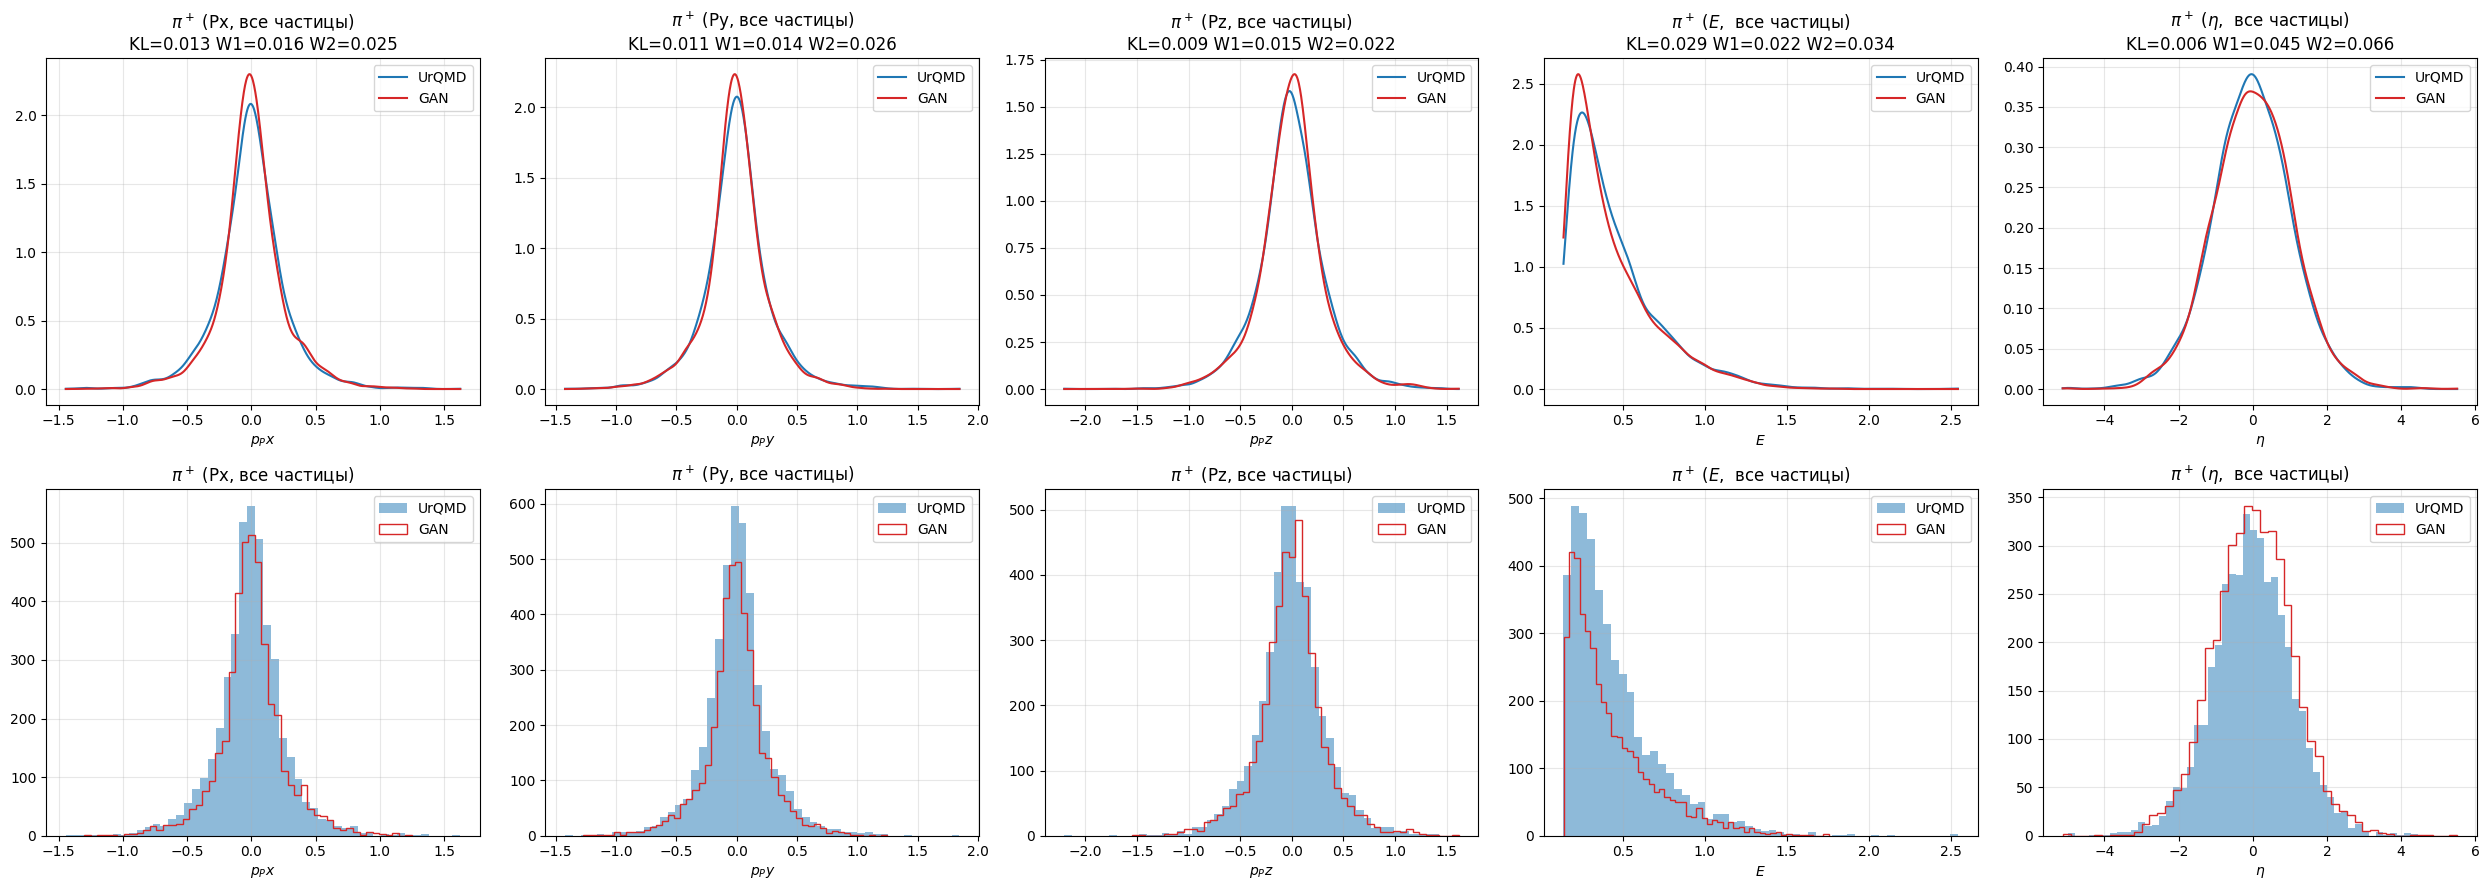

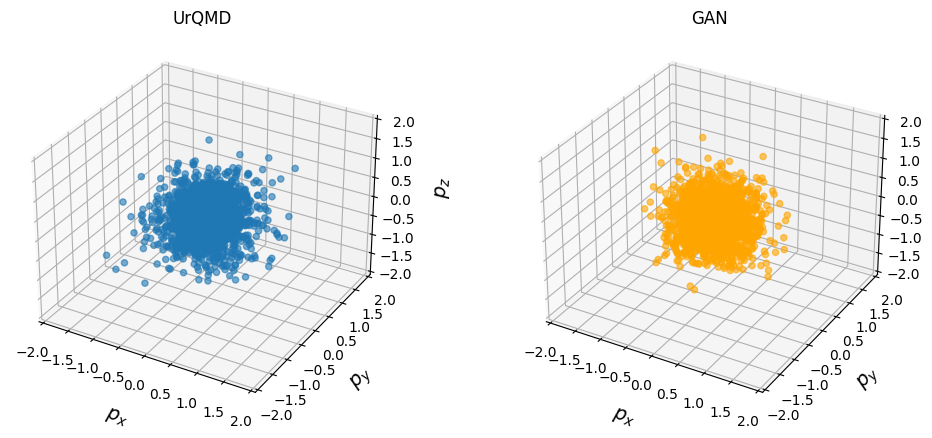

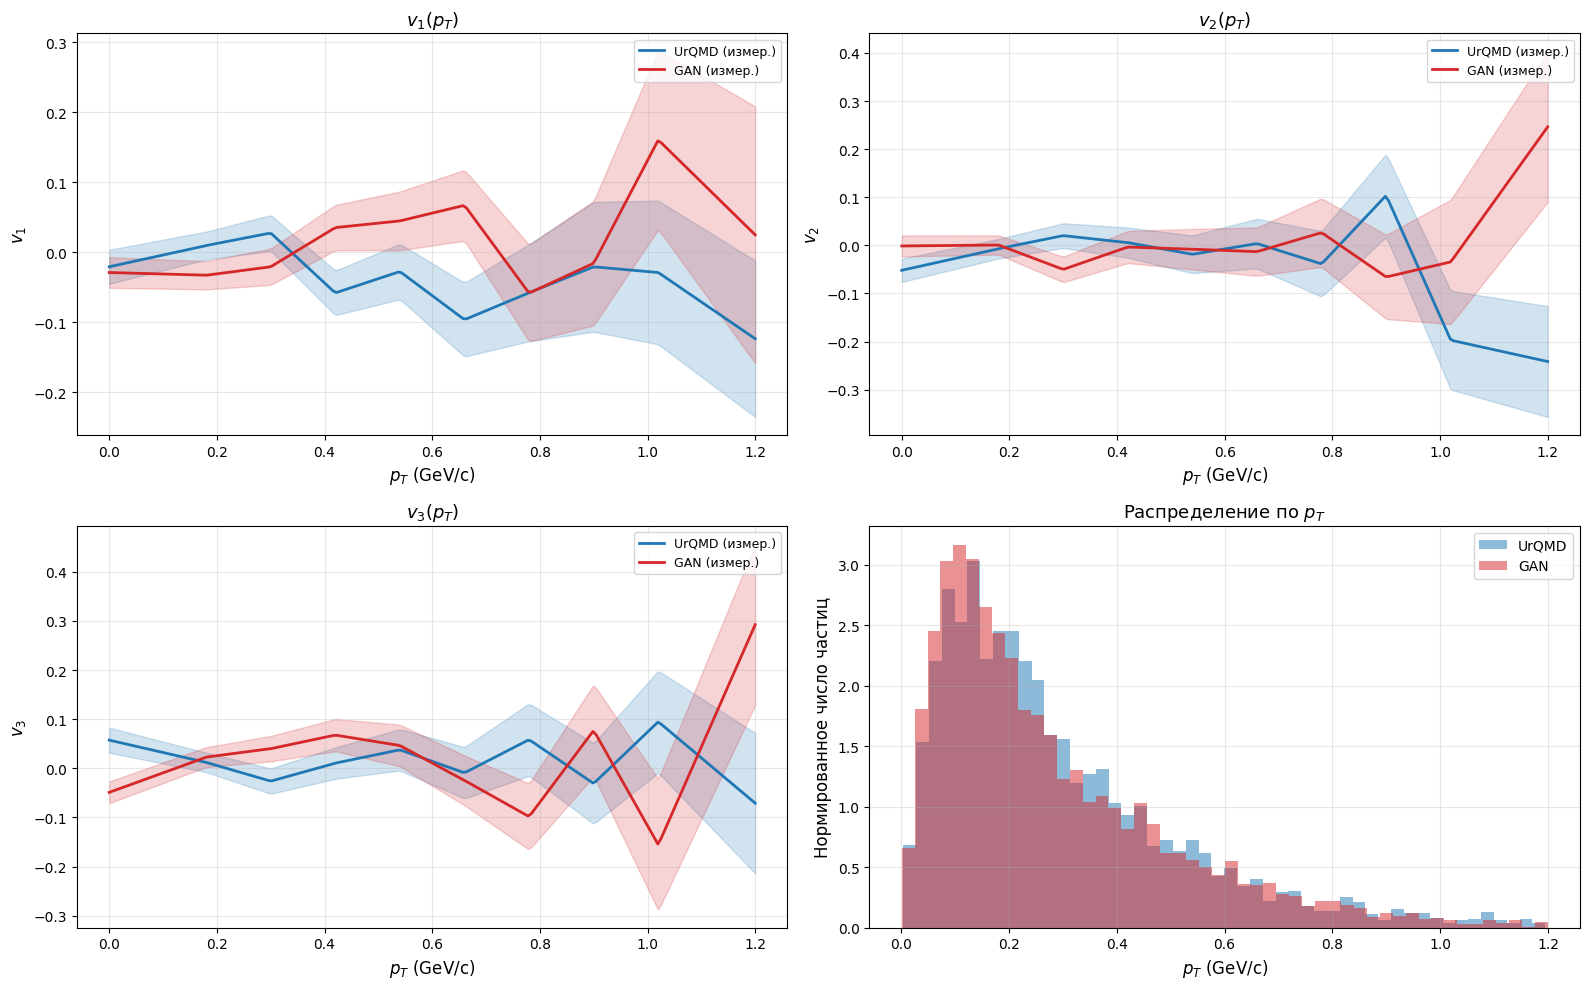

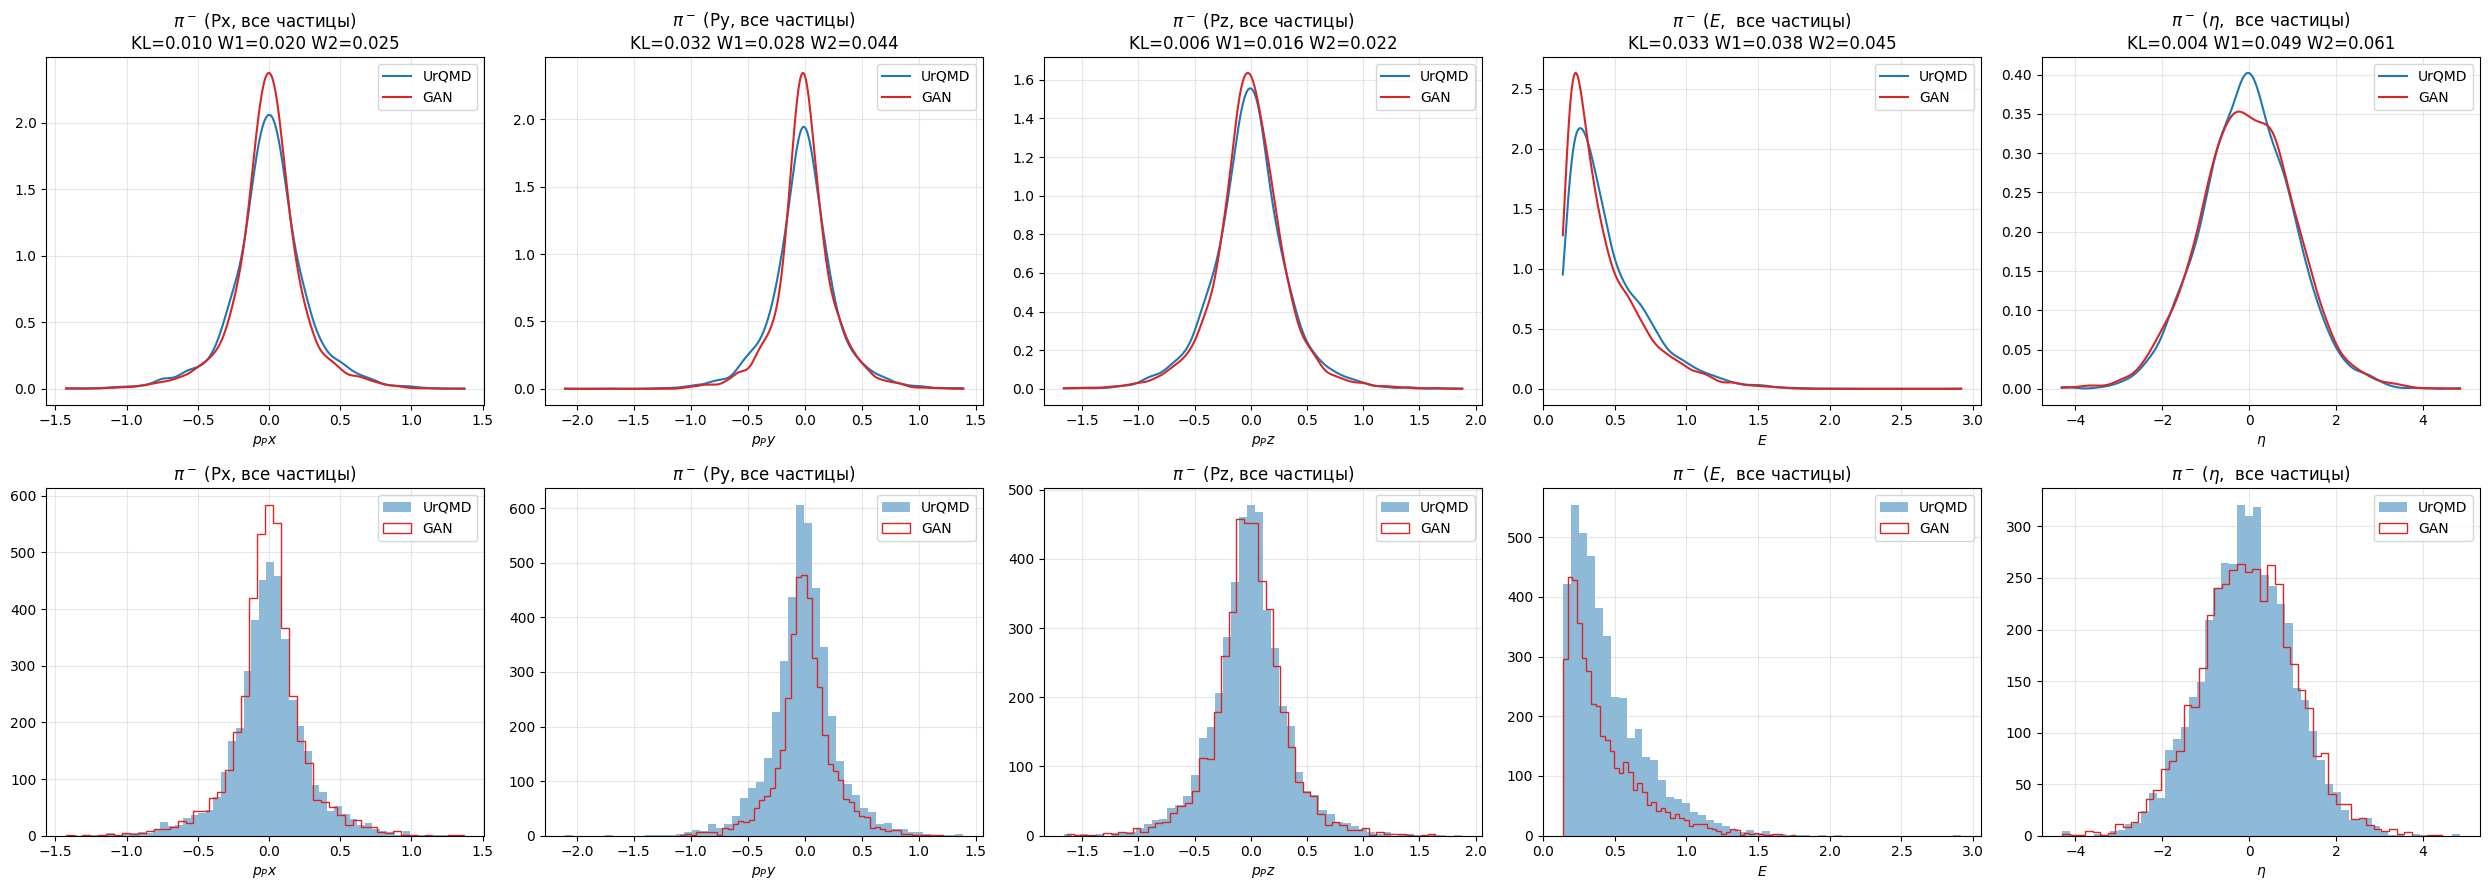

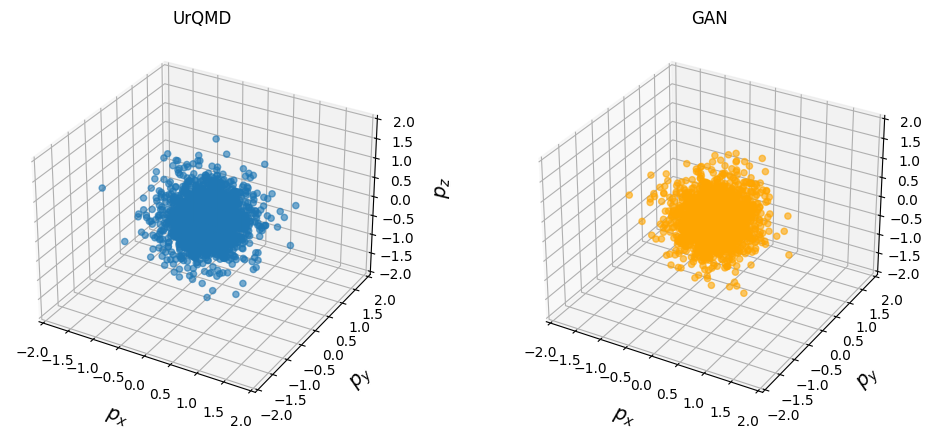

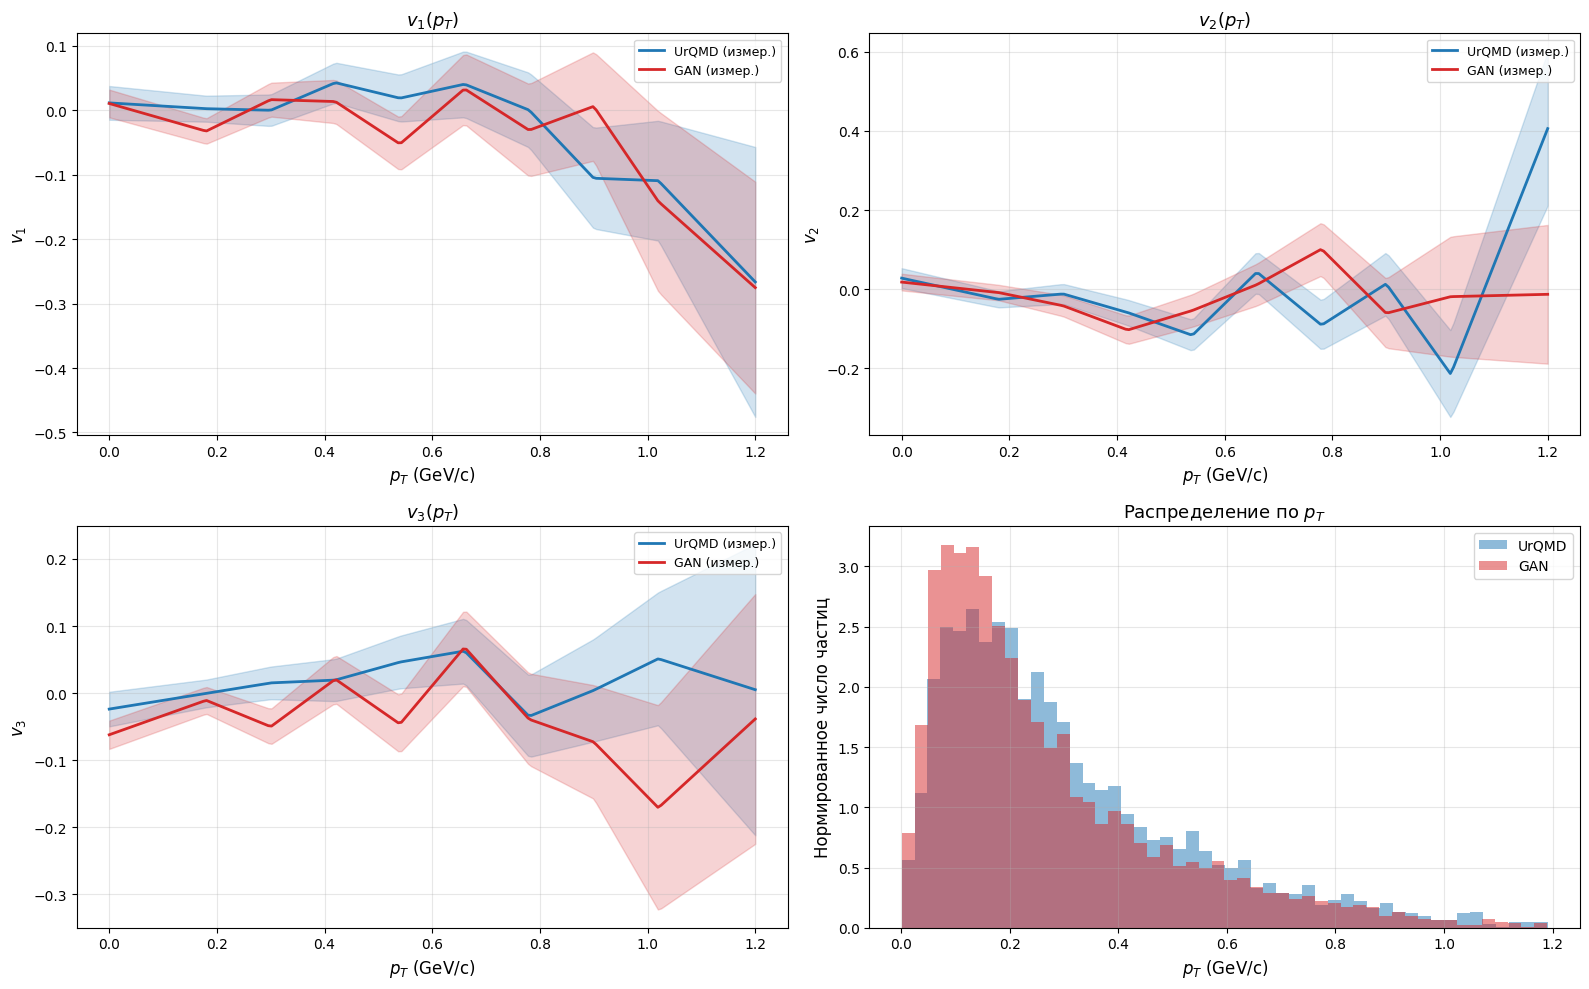

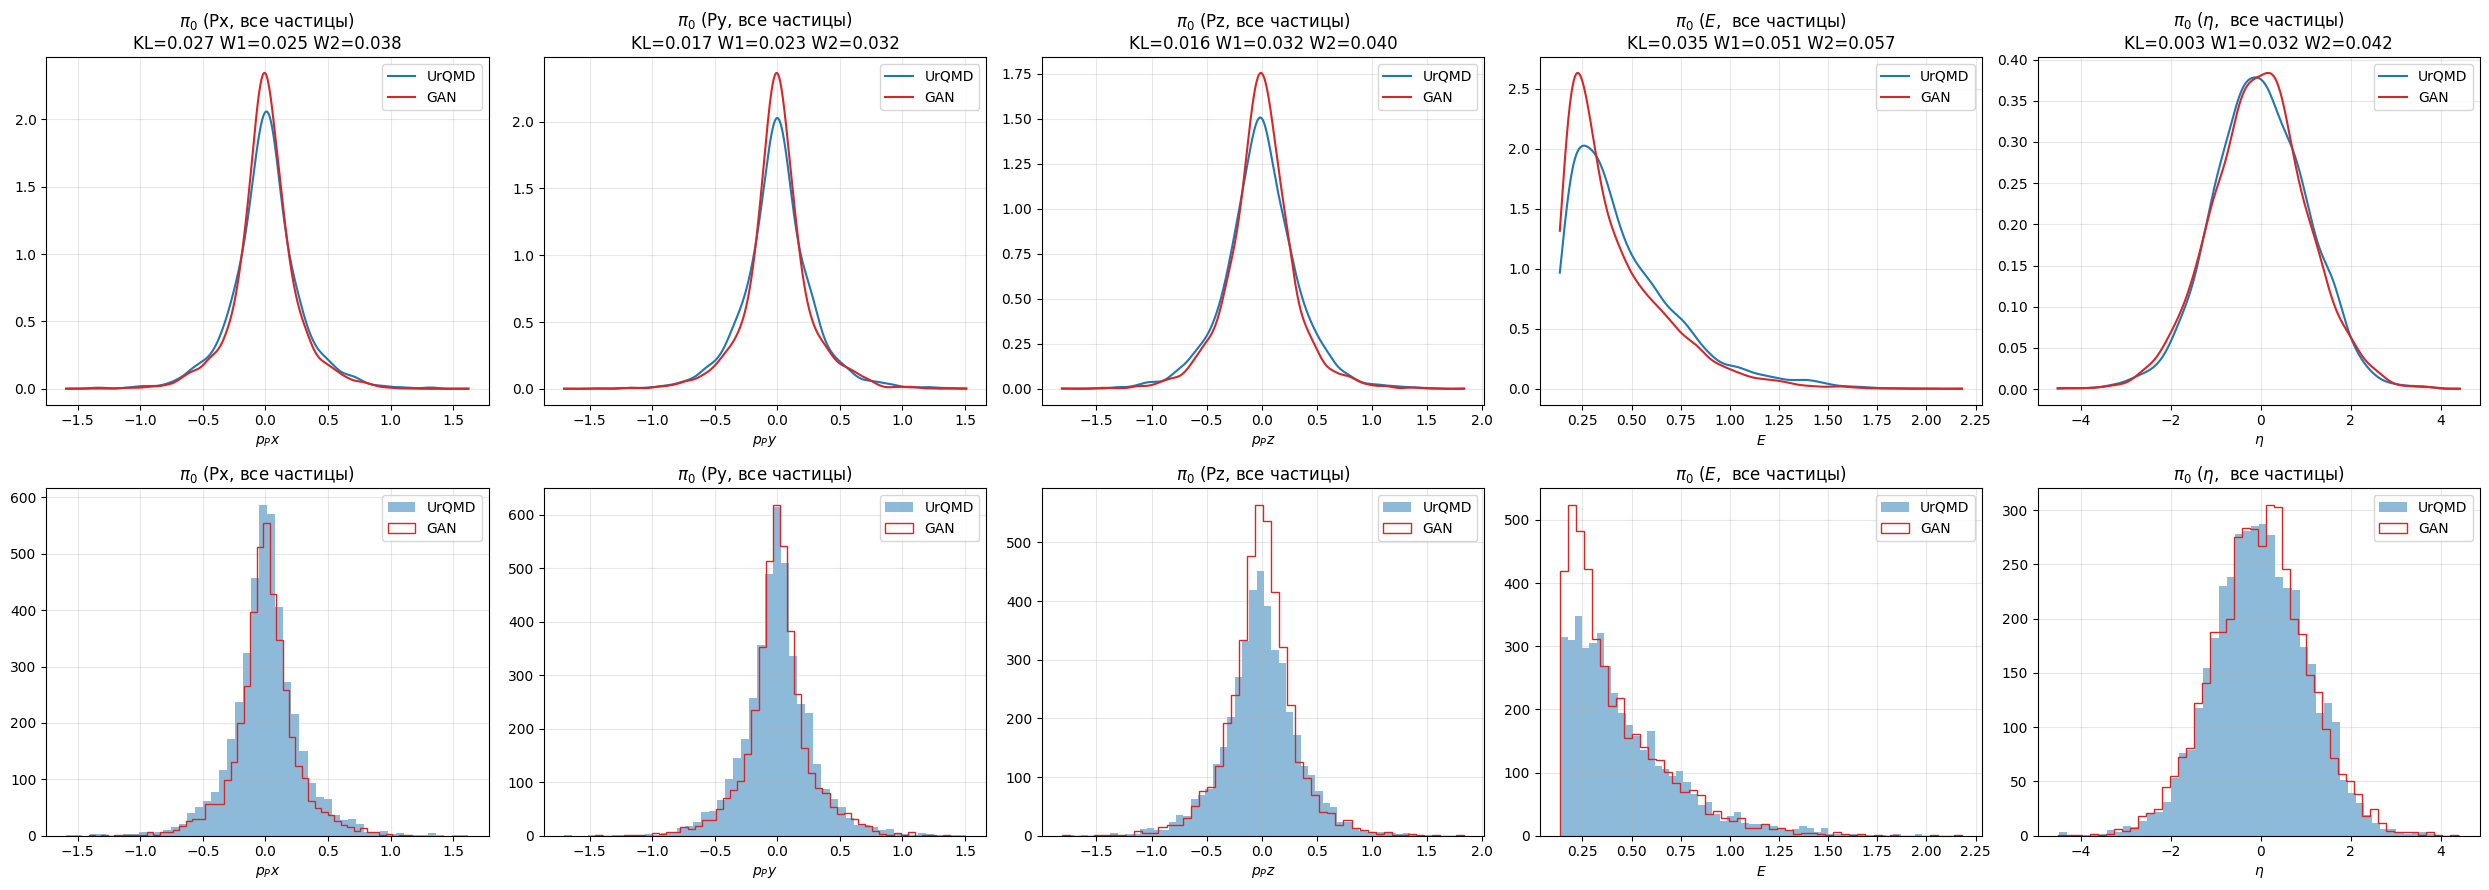

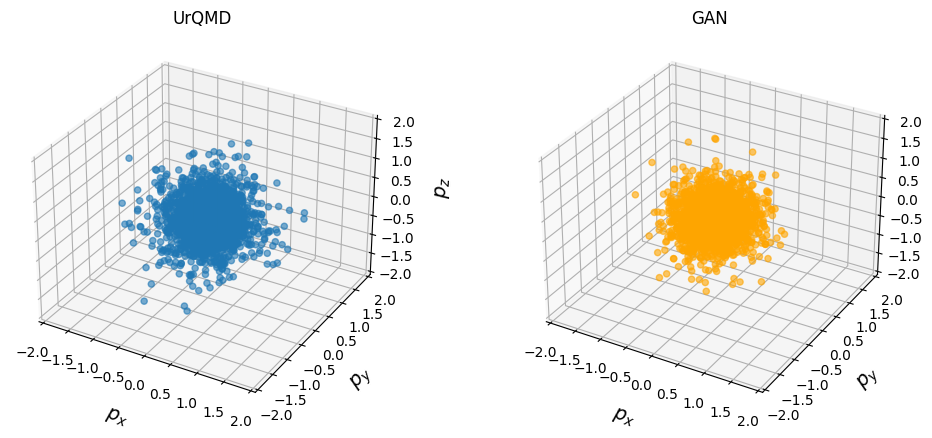

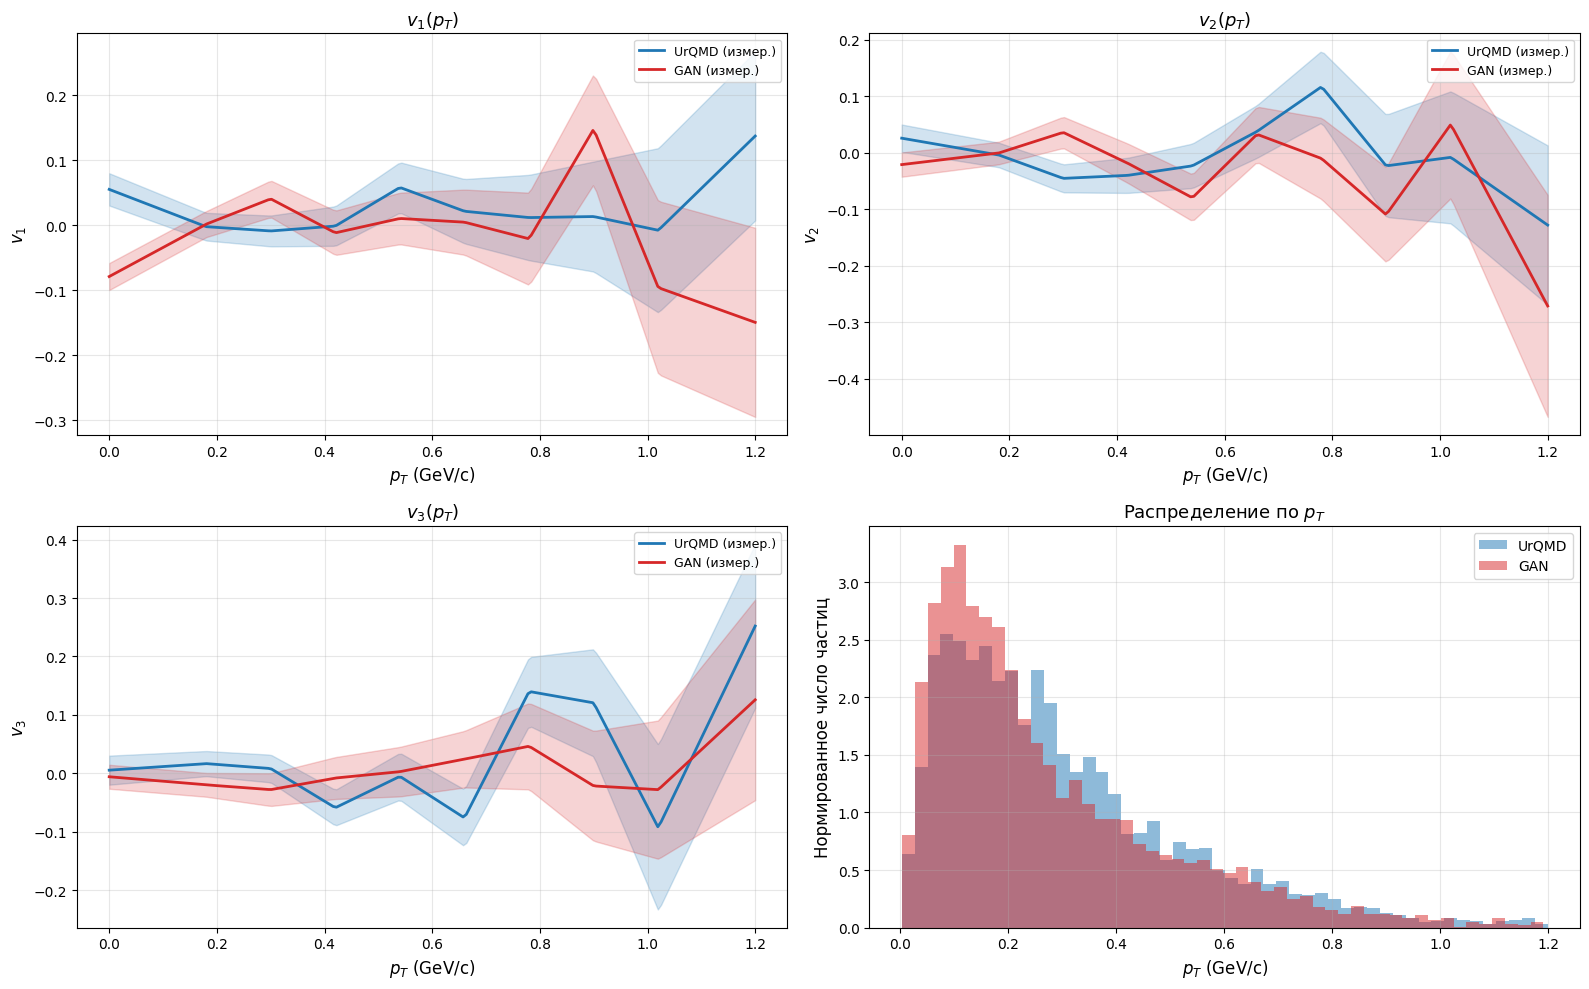

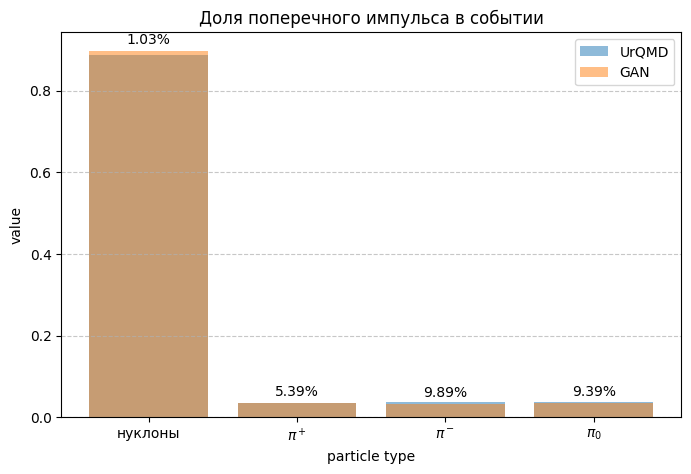

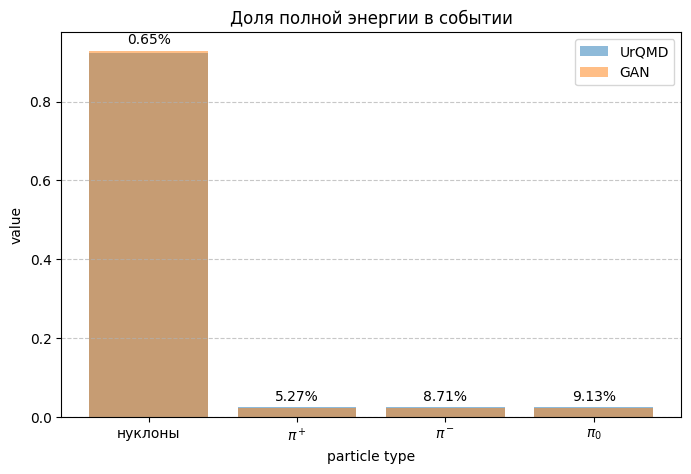

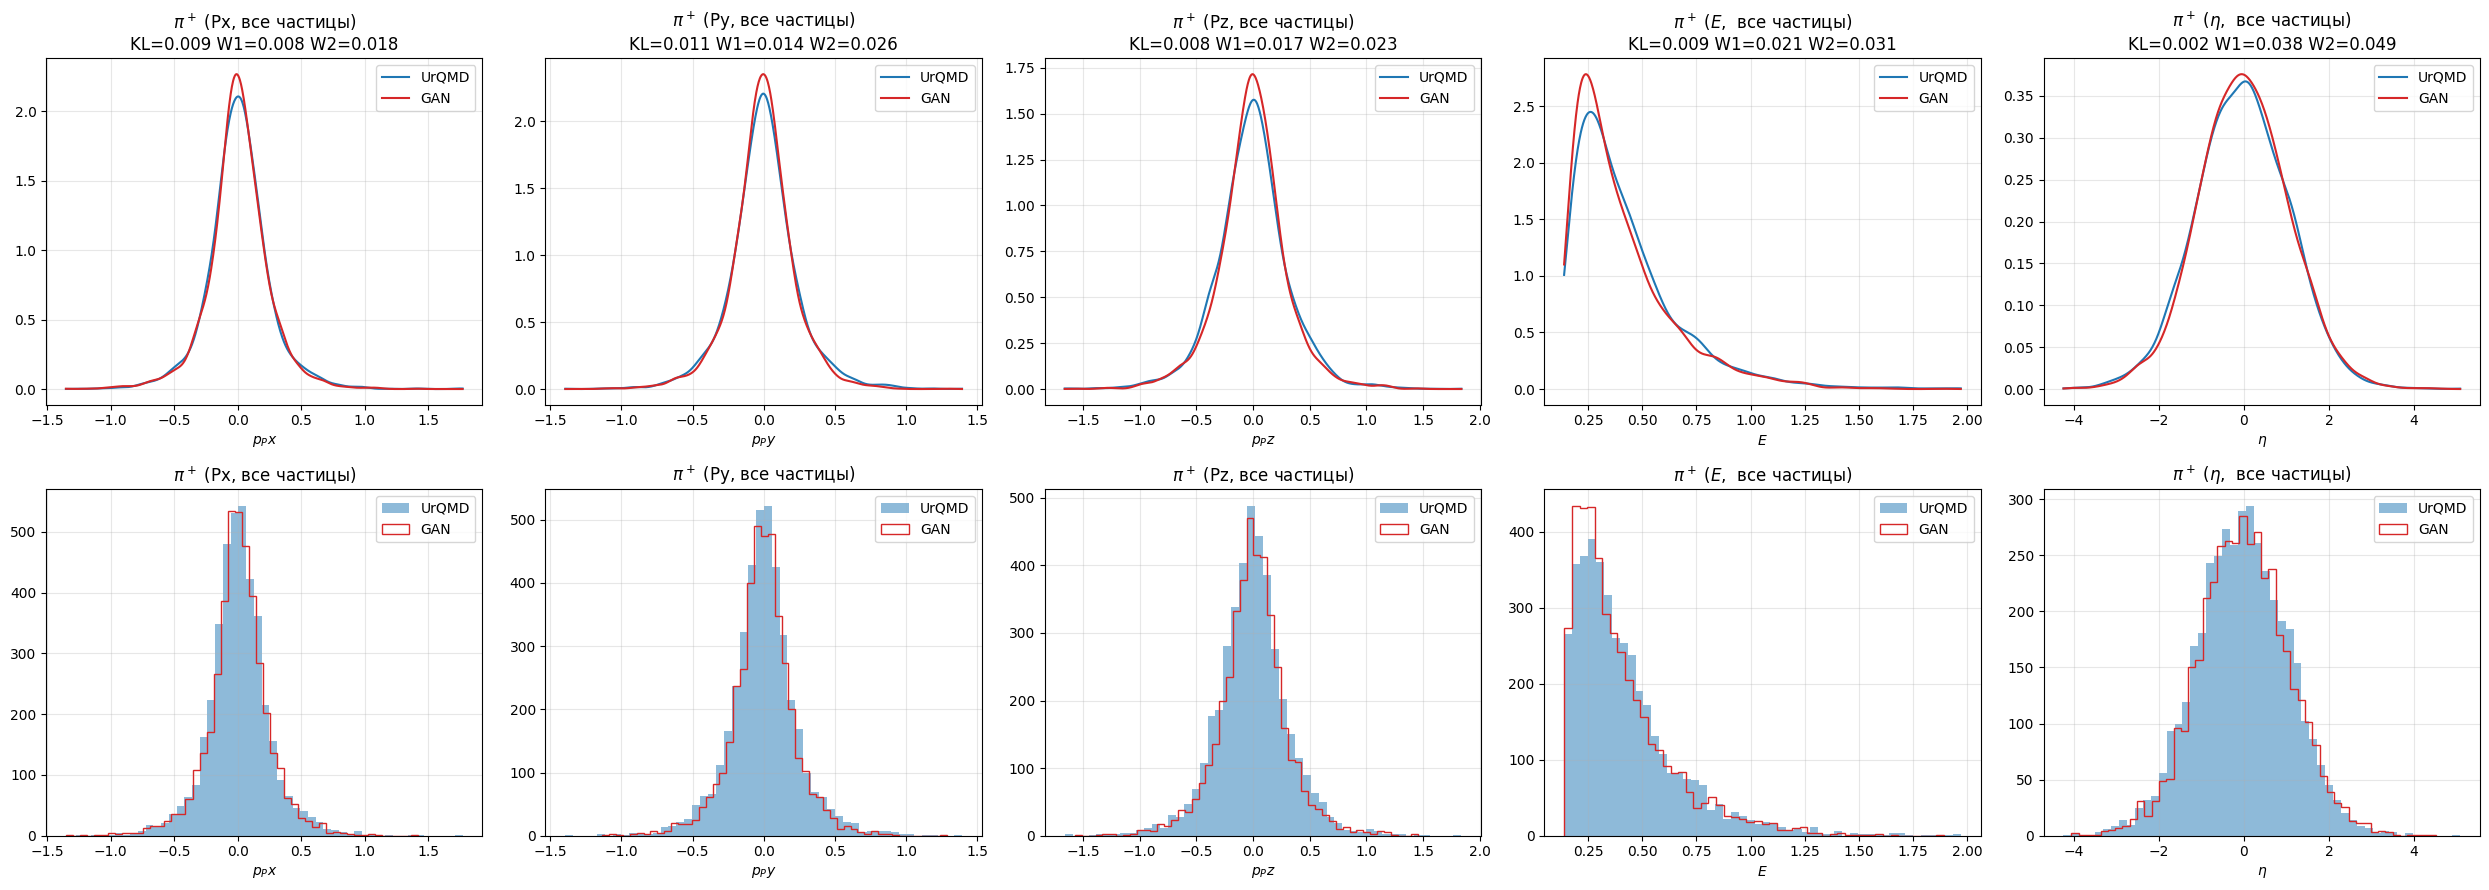

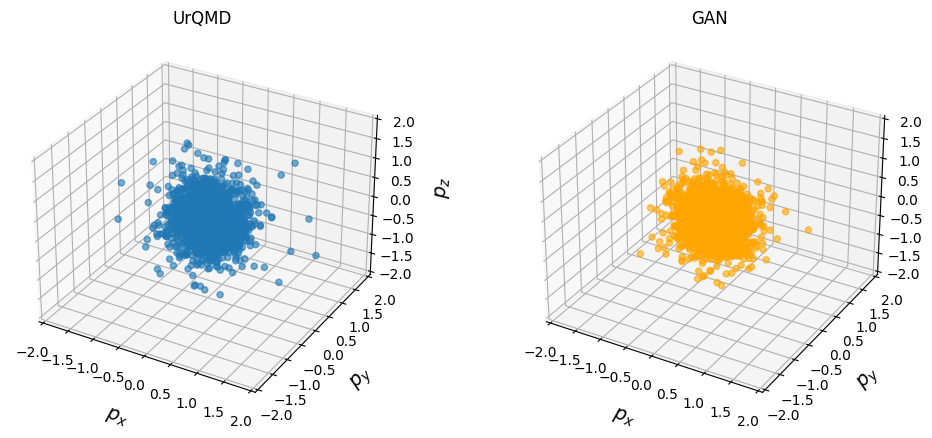

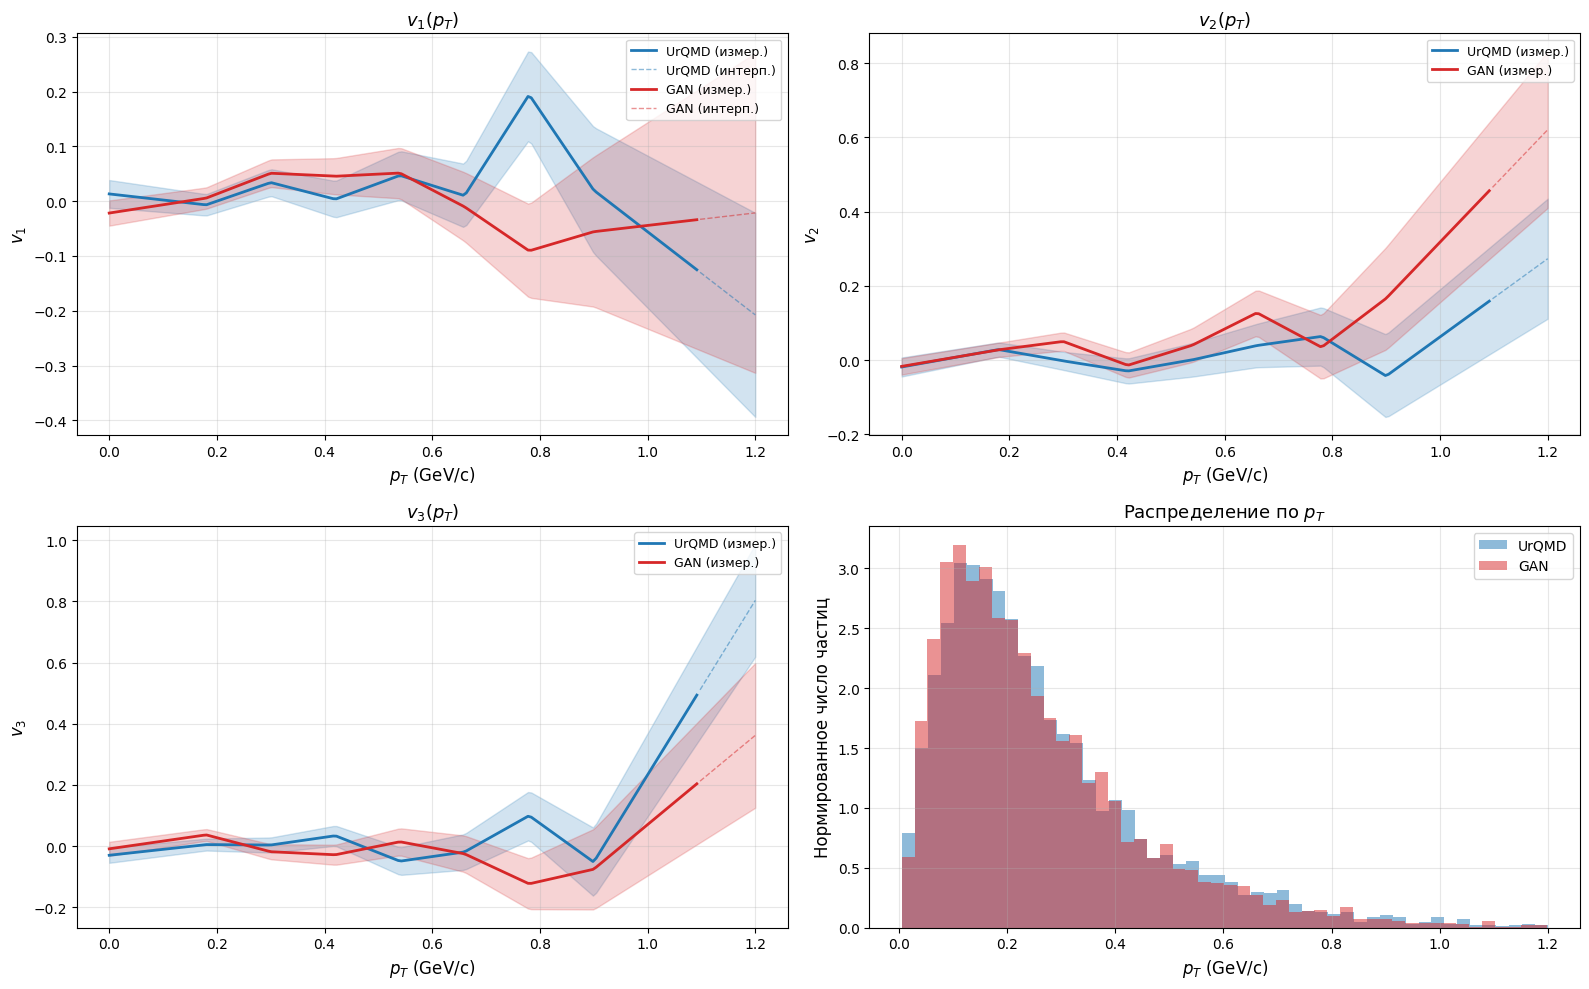

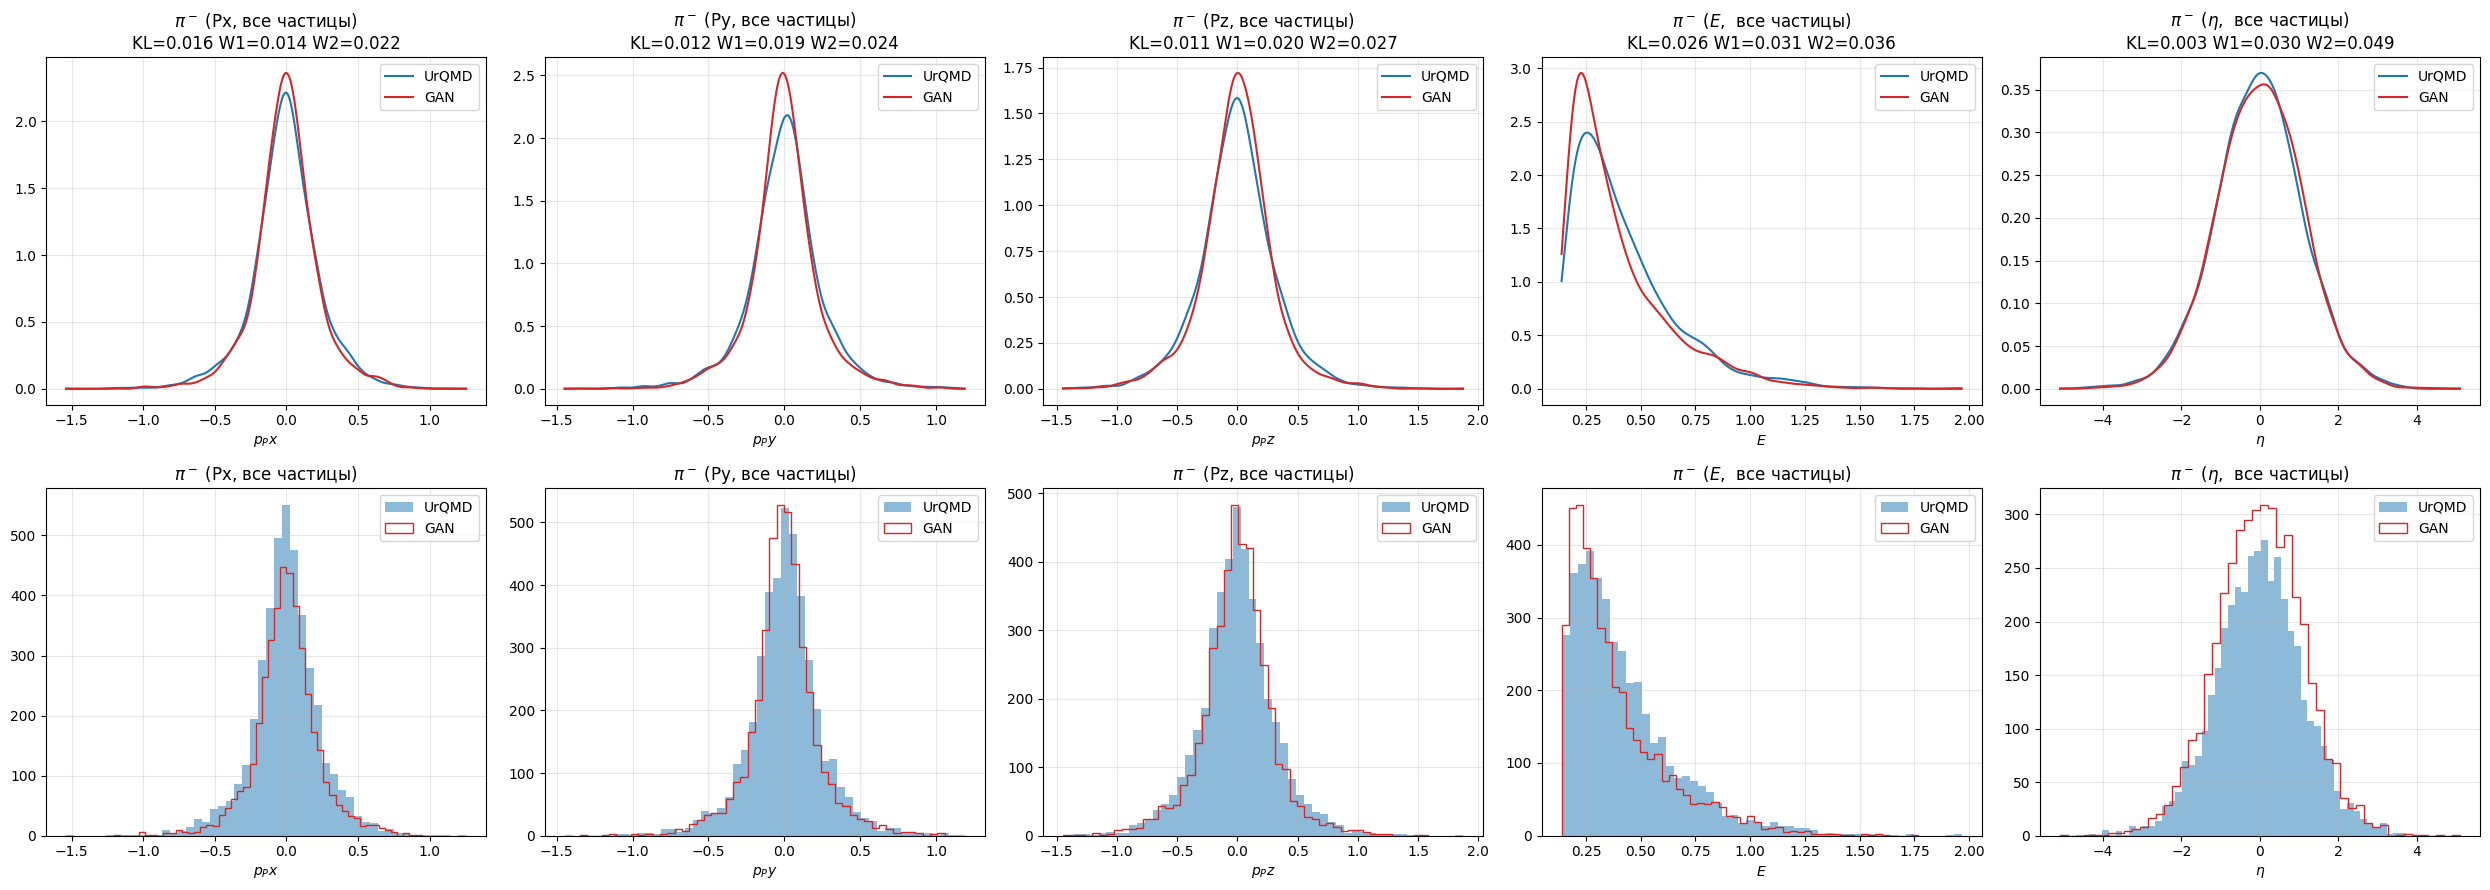

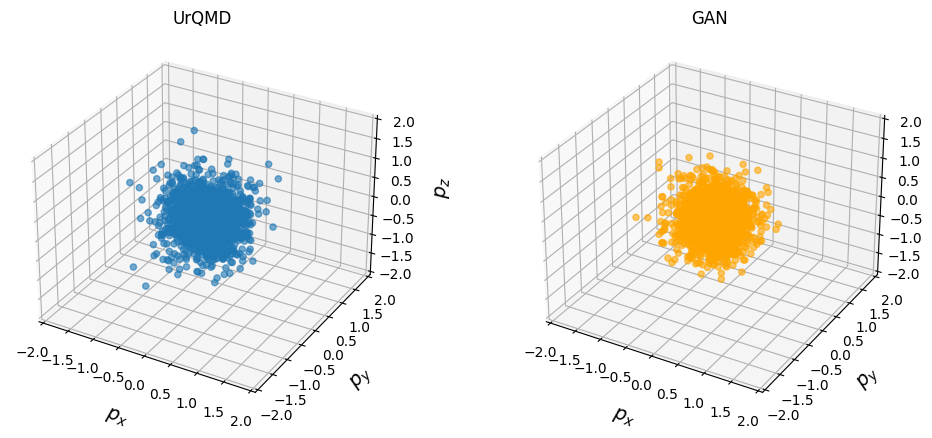

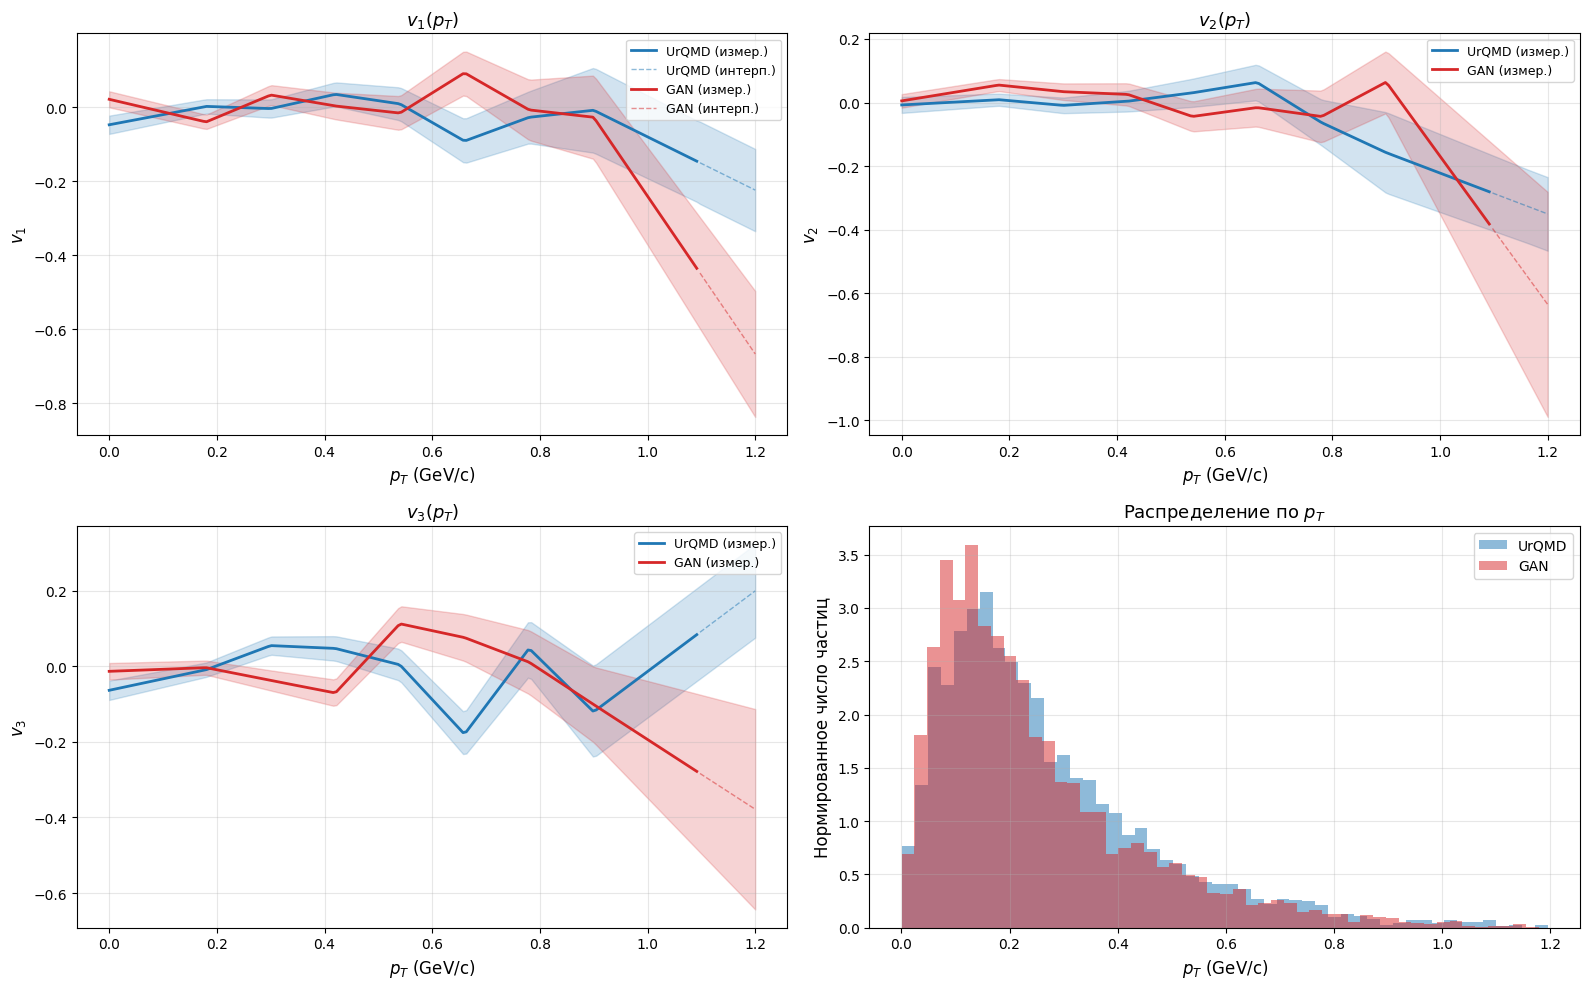

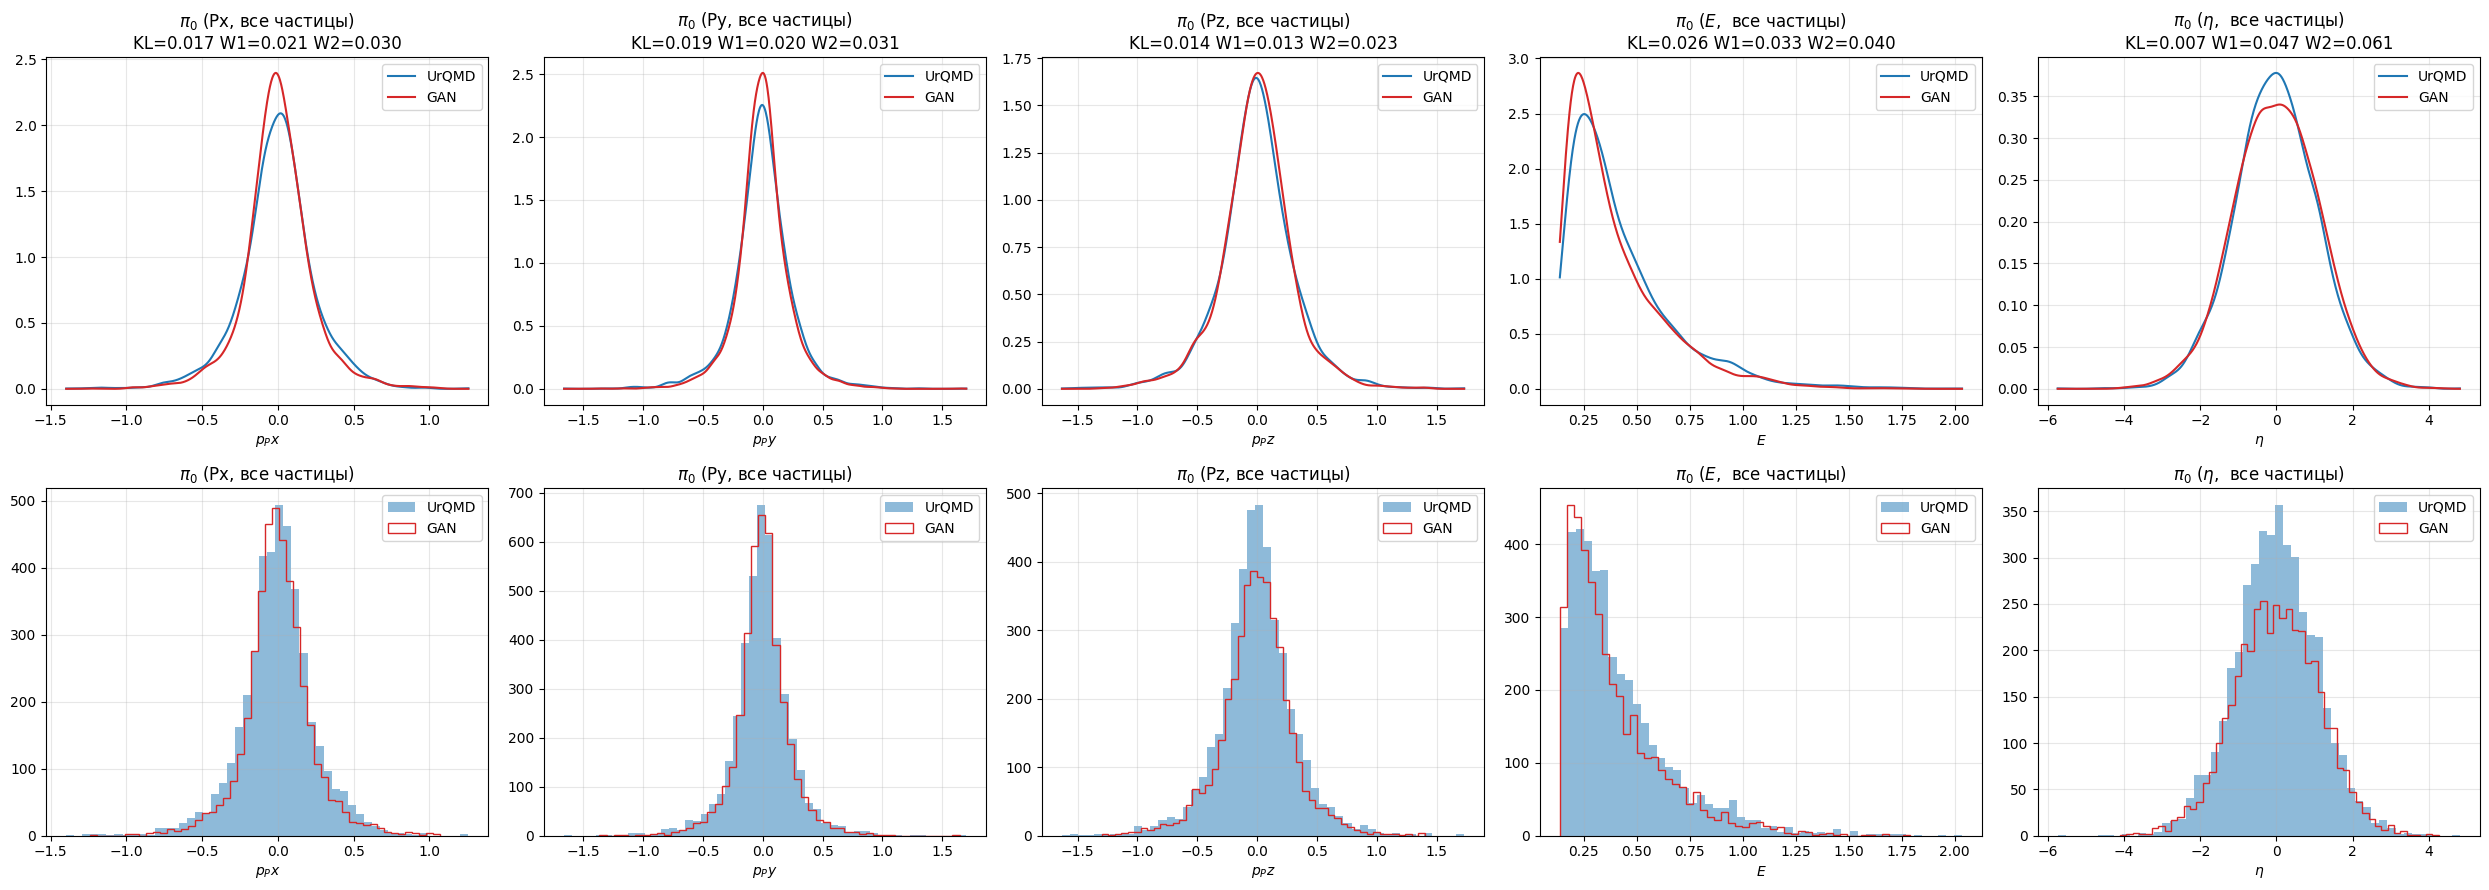

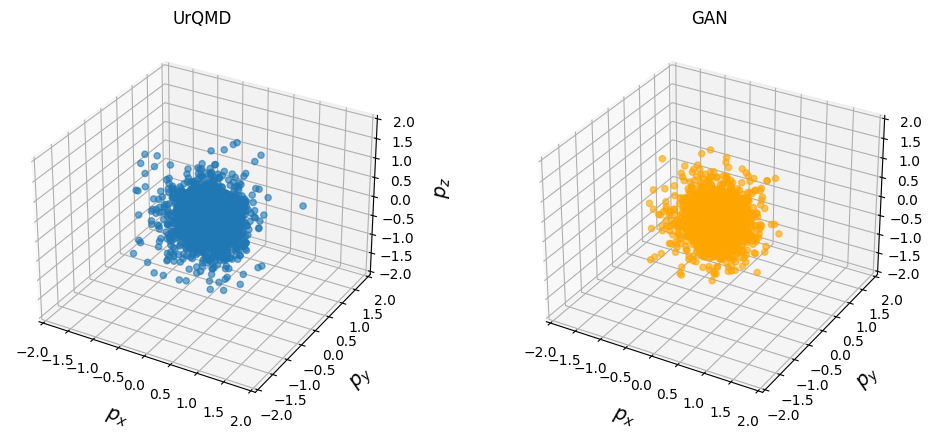

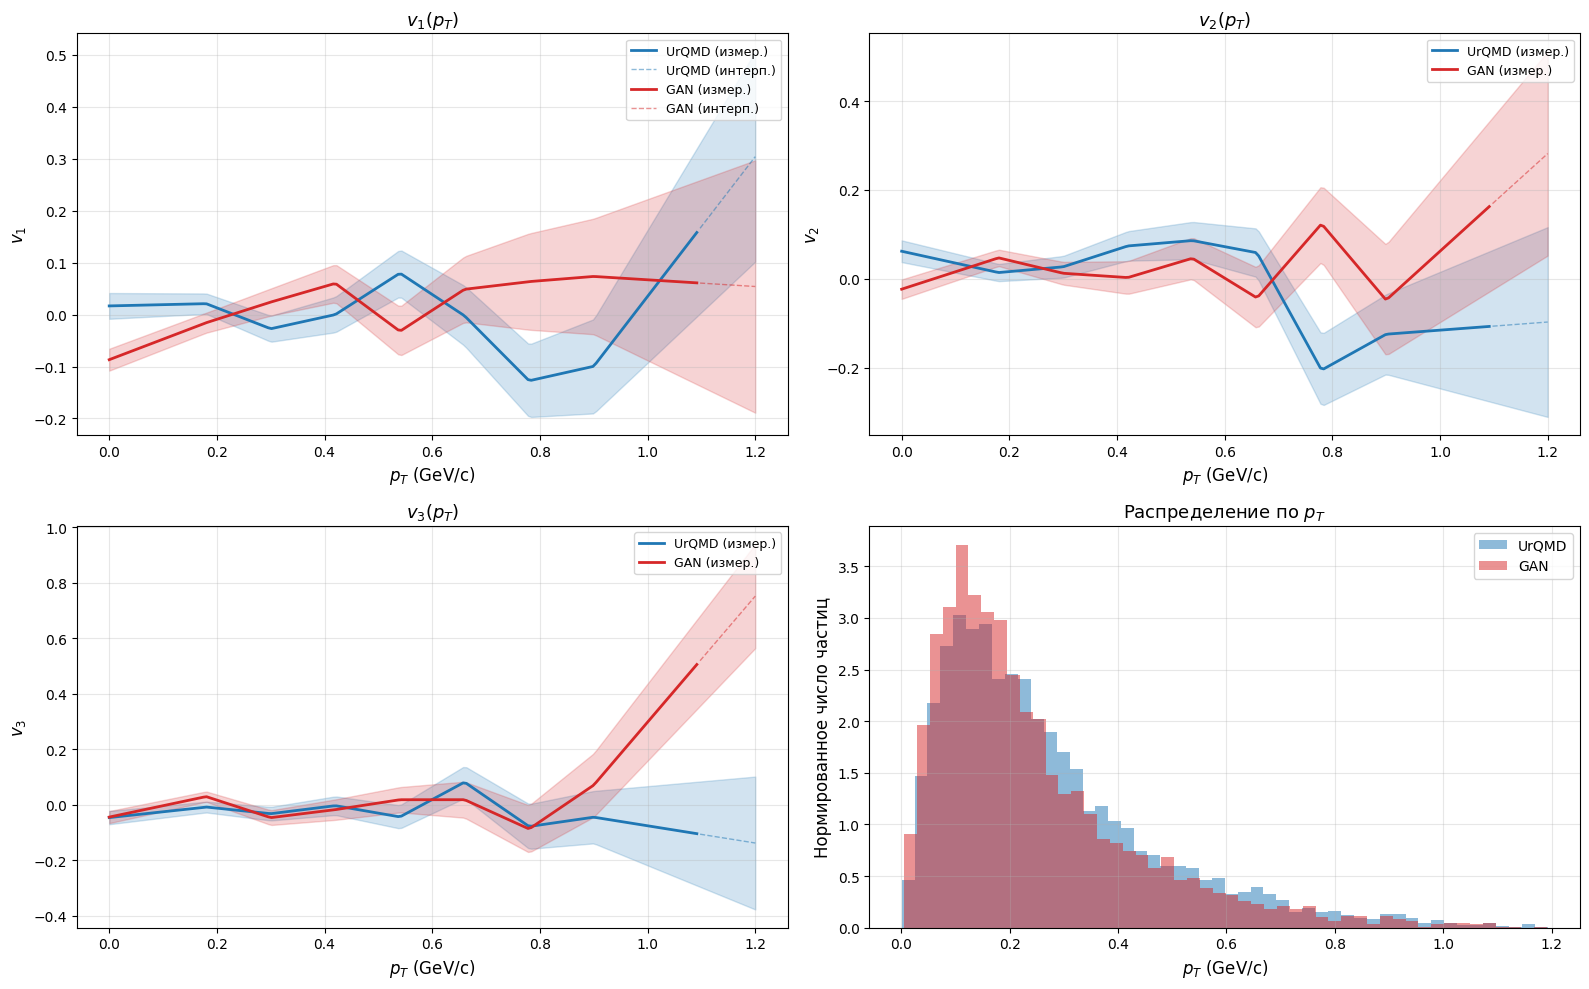

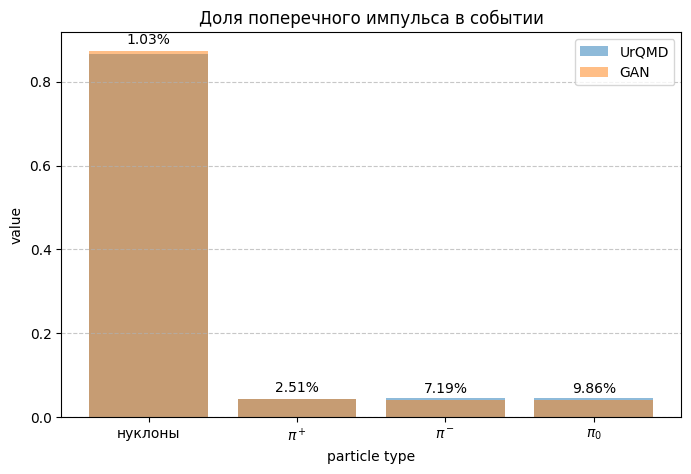

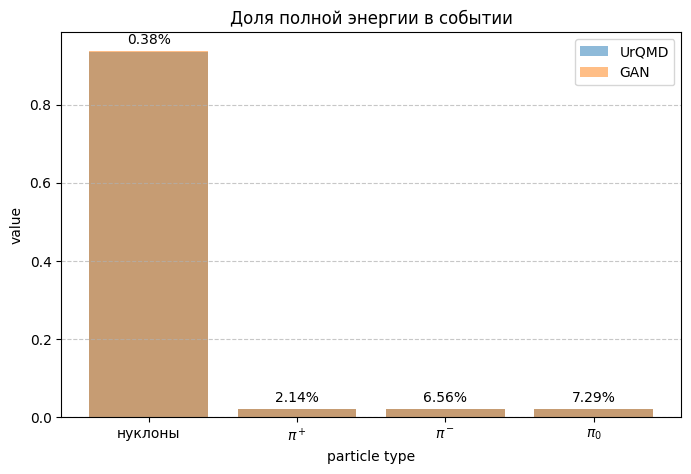

In [17]:
if not os.path.exists("xexe_eos_1_bmn.root"):
    gdown.download("https://drive.google.com/uc?id=1EhDJ0DSe1AuHNRxUIbQV5r8AXo4TP8Kp")
if not os.path.exists("xexe_urqmd_5fm.root"):
    gdown.download("https://drive.google.com/uc?id=1mBNT9X2qJRgRFHAhRIfv6kFSHQRnbZ4T")

urqmd_1_7 = uproot.open("xexe_eos_1_bmn.root:events").arrays(library="pd")
urqmd_1_7_inv = urqmd_1_7.copy()
urqmd_1_7_inv["fParticles.fPx"] = urqmd_1_7_inv["fParticles.fPx"].apply(
    lambda x: (-np.array(x)).tolist()
)
urqmd_1_7_inv["fParticles.fPy"] = urqmd_1_7_inv["fParticles.fPy"].apply(
    lambda x: (-np.array(x)).tolist()
)
urqmd_1_7 = pd.concat([urqmd_1_7, urqmd_1_7_inv], ignore_index=True)
urqmd_5 = uproot.open("xexe_urqmd_5fm.root:events").arrays(library="pd")

set_seed(seeds[0])
ratio = 1
train_n_1_7 = int(0.8 * len(urqmd_1_7))
val_n_1_7 = (len(urqmd_1_7) - train_n_1_7) // 2
train_n_5 = ratio * train_n_1_7
val_n_5 = ratio * val_n_1_7
ids_1_7 = np.random.permutation(len(urqmd_1_7))
ids_5 = np.random.permutation(len(urqmd_5))
urqmd_train_1_7 = urqmd_1_7.iloc[ids_1_7[:train_n_1_7]]
urqmd_val_1_7 = urqmd_1_7.iloc[ids_1_7[train_n_1_7 : train_n_1_7 + val_n_1_7]]
urqmd_test_1_7 = urqmd_1_7.iloc[
    ids_1_7[train_n_1_7 + val_n_1_7 : train_n_1_7 + val_n_1_7 * 2]
]
urqmd_train_5 = urqmd_5.iloc[ids_5[:train_n_5]]
urqmd_val_5 = urqmd_5.iloc[ids_5[train_n_5 : train_n_5 + val_n_5]]
urqmd_test_5 = urqmd_5.iloc[ids_5[train_n_5 + val_n_5 : train_n_5 + val_n_5 * 2]]
urqmd_train = pd.concat([urqmd_train_1_7, urqmd_train_5], ignore_index=True)
urqmd_val = pd.concat([urqmd_val_1_7, urqmd_val_5], ignore_index=True)

COUNT = {}
for code in particles:
    selected = (
        urqmd_train["fParticles.fPdg"]
        .apply(lambda x: (np.array(x) == code).sum())
        .values
    )
    final = int(np.percentile(selected, 0.95)) if code in pions else selected.max()
    if final == 0:
        final = int(selected.max())
    COUNT[code] = final
meson_max = max({k: v for k, v in COUNT.items() if k not in nucleons}.values())
nucleon_max = max({k: v for k, v in COUNT.items() if k in nucleons}.values())

train, cond_cols, nucl_cols, nucl_mask_cols = preprocess_urqmd(
    urqmd_train, max_size_t=meson_max, max_size_c=nucleon_max, return_cols=True
)
val = preprocess_urqmd(urqmd_val, max_size_t=meson_max, max_size_c=nucleon_max)
test_1_7 = preprocess_urqmd(
    urqmd_test_1_7, max_size_t=meson_max, max_size_c=nucleon_max
)
test_5 = preprocess_urqmd(urqmd_test_5, max_size_t=meson_max, max_size_c=nucleon_max)

extern_cond_d = len(cond_cols)

use_shadow = True

cond_stats = {}
for col in cond_cols:
    m, s = train[col].mean(), train[col].std()
    cond_stats[col] = (m, s)
    train[col] = (train[col] - m) / s
    val[col] = (val[col] - m) / s
    test_1_7[col] = (test_1_7[col] - m) / s
    test_5[col] = (test_5[col] - m) / s

train_dataset = TensorDataset(
    torch.tensor(list(train["target_moms"].values), dtype=torch.float32),
    torch.tensor(train[cond_cols].values, dtype=torch.float32),
    torch.tensor(train["label"].values),
    torch.tensor(list(train["target_mask"].values), dtype=torch.float32),
)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

val_dataset = TensorDataset(
    torch.tensor(list(val["target_moms"].values), dtype=torch.float32),
    torch.tensor(val[cond_cols].values, dtype=torch.float32),
    torch.tensor(val["label"].values),
    torch.tensor(list(val["target_mask"].values), dtype=torch.float32),
)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

G = Pion_Gan_Generator(
    latent_global=latent_dim,
    latent_local=latent_local_dim,
    num_labels=num_classes,
    feats=feat_dim,
    max_len=meson_max,
    d_model=hid_dim,
    n_heads=n_heads,
    extern_cond_d=extern_cond_d,
    d_ff=hid_dim * 2,
    n_modes=n_modes,
    n_layers=num_layers_gen,
    use_learnable_noise=False,
    use_weight_norm=(not use_shadow),
).to(device)

D = Pion_Gan_Discriminator(
    num_labels=num_classes,
    feats=feat_dim,
    d_model=hid_dim,
    n_heads=n_heads,
    d_ff=hid_dim * 2,
    extern_cond_d=extern_cond_d,
    n_layers=num_layers_disc,
    use_weight_norm=(not use_shadow),
).to(device)

opt_G = torch.optim.Adam(G.parameters(), lr=1e-4, betas=(0.5, 0.9))
opt_D = torch.optim.Adam(D.parameters(), lr=1e-4, betas=(0.5, 0.9))

if use_shadow:
    G_shadow = deepcopy(G).eval()
    update_average(G_shadow, G, beta=0.0)
else:
    G_shadow = G

epochs_urqmd = 100
loss_hist_urqmd = {"d_loss": [], "g_loss": [], "flow_loss": []}
best_flow_loss = float("inf")

for epoch in range(1, epochs_urqmd + 1):
    ep_loss = train_epoch(
        G,
        D,
        train_loader,
        opt_G,
        opt_D,
        device,
        d_iters=1,
        lambda_gp=10,
        lambda_flow=0.05,
        clip_val=1.0,
        use_shadow=use_shadow,
        G_shadow=G_shadow,
        ema_beta=0.999,
    )
    for k, v in ep_loss.items():
        loss_hist_urqmd[k].append(v)

    G_shadow.eval()
    val_flow = 0.0
    num_val_batches = 0
    for val_batch in val_loader:
        val_flow += get_flow_metric(G_shadow, val_batch, device)
        num_val_batches += 1
    avg_val_flow = val_flow / num_val_batches if num_val_batches > 0 else float("inf")
    G_shadow.train()

    if avg_val_flow < best_flow_loss:
        best_flow_loss = avg_val_flow
        torch.save(G.state_dict(), "_best_urqmd_flow_g.pt")
        torch.save(D.state_dict(), "_best_urqmd_flow_d.pt")
        torch.save(G_shadow.state_dict(), "_best_urqmd_flow_g_shadow.pt")

    if epoch % 10 == 0:
        plot_losses(loss_hist_urqmd)
        get_dist_metrics(
            G_shadow,
            generate_transformer,
            meson_max,
            list(val["target_moms"].values),
            val[cond_cols].values.astype(float),
            val["label"].values,
            list(val["target_mask"].values),
            device,
        )
        # get_energy_metrics(
        #    G_shadow,
        #    generate_transformer,
        #    meson_max,
        #    list(val["target_moms"].values),
        #    list(val[nucl_cols[0]].values),
        #    list(val[nucl_mask_cols[0]].values),
        #    val['event'].values,
        #    val[cond_cols].values.astype(float),
        #    val["label"].values,
        #    list(val["target_mask"].values),
        #    device
        # )

G.load_state_dict(torch.load("_best_urqmd_flow_g.pt"))
D.load_state_dict(torch.load("_best_urqmd_flow_d.pt"))
if use_shadow:
    G_shadow.load_state_dict(torch.load("_best_urqmd_flow_g_shadow.pt"))
else:
    G_shadow = G

clear_output()

METRICS = {}
METRICS["urqmd_1.7"] = {}
METRICS["urqmd_5"] = {}
_ = get_metrics(
    G_shadow,
    test_1_7,
    cond_cols,
    nucl_cols,
    nucl_mask_cols,
    meson_max,
    device,
    final_metrics=METRICS["urqmd_1.7"],
    real_name="UrQMD",
)
_ = get_metrics(
    G_shadow,
    test_5,
    cond_cols,
    nucl_cols,
    nucl_mask_cols,
    meson_max,
    device,
    final_metrics=METRICS["urqmd_5"],
    real_name="UrQMD",
)

In [18]:
def freeze(module, freeze=True):
    for param in module.parameters():
        param.requires_grad = not freeze


def finetune(G, D):
    freeze(G.emb)
    freeze(G.global_proj)
    freeze(G.local_proj)
    freeze(G.local_sampler)
    freeze(G.global_sampler)
    for i in range(3):
        if i < len(G.blocks):
            freeze(G.blocks[i])
    freeze(D.emb)
    freeze(D.input_proj)
    for i in range(3):
        if i < len(D.blocks):
            freeze(D.blocks[i])
    return G, D

In [19]:
smash_file = "smash_particles_xecs_2.87gev_hardSkyrme_defaultSpot_10943245_10.root"
if not os.path.exists(smash_file):
    gdown.download("https://drive.google.com/uc?id=1BrMboOkpiwmMfJO0PStSxUmiLqWqYHi_")
smash = uproot.open(smash_file)["particles;1"]
df_smash = smash.arrays(library="pd")
if "fB" not in df_smash.columns:
    df_smash["fB"] = np.random.uniform(0, 15, size=len(df_smash))

n_smash_train = int(0.7 * len(df_smash))
n_smash_val = int(0.15 * len(df_smash))
ids_smash = np.random.permutation(list(range(len(df_smash))))
smash_train = df_smash.iloc[ids_smash[:n_smash_train]]
smash_val = df_smash.iloc[ids_smash[n_smash_train : n_smash_train + n_smash_val]]
smash_test = df_smash.iloc[
    ids_smash[n_smash_train + n_smash_val : n_smash_train + 2 * n_smash_val]
]

smash_train_final, cond_cols, nucl_cols, nucl_mask_cols = preprocess_smash(
    smash_train, max_size_t=meson_max, max_size_c=nucleon_max, return_cols=True
)
smash_val_final = preprocess_smash(
    smash_val, max_size_t=meson_max, max_size_c=nucleon_max
)
smash_test_final = preprocess_smash(
    smash_test, max_size_t=meson_max, max_size_c=nucleon_max
)

cond_stats = {}
for col in cond_cols:
    m, s = smash_train_final[col].mean(), smash_train_final[col].std()
    cond_stats[col] = (m, s)
    smash_train_final[col] = (smash_train_final[col] - m) / s
    smash_val_final[col] = (smash_val_final[col] - m) / s
    smash_test_final[col] = (smash_test_final[col] - m) / s

smash_train_dataset = TensorDataset(
    torch.tensor(list(smash_train_final["target_moms"].values), dtype=torch.float32),
    torch.tensor(smash_train_final[cond_cols].values, dtype=torch.float32),
    torch.tensor(smash_train_final["label"].values),
    torch.tensor(list(smash_train_final["target_mask"].values), dtype=torch.float32),
)
smash_train_loader = DataLoader(
    smash_train_dataset, batch_size=batch_size, shuffle=True
)

smash_val_dataset = TensorDataset(
    torch.tensor(list(smash_val_final["target_moms"].values), dtype=torch.float32),
    torch.tensor(smash_val_final[cond_cols].values, dtype=torch.float32),
    torch.tensor(smash_val_final["label"].values),
    torch.tensor(list(smash_val_final["target_mask"].values), dtype=torch.float32),
)
smash_val_loader = DataLoader(smash_val_dataset, batch_size=batch_size, shuffle=False)

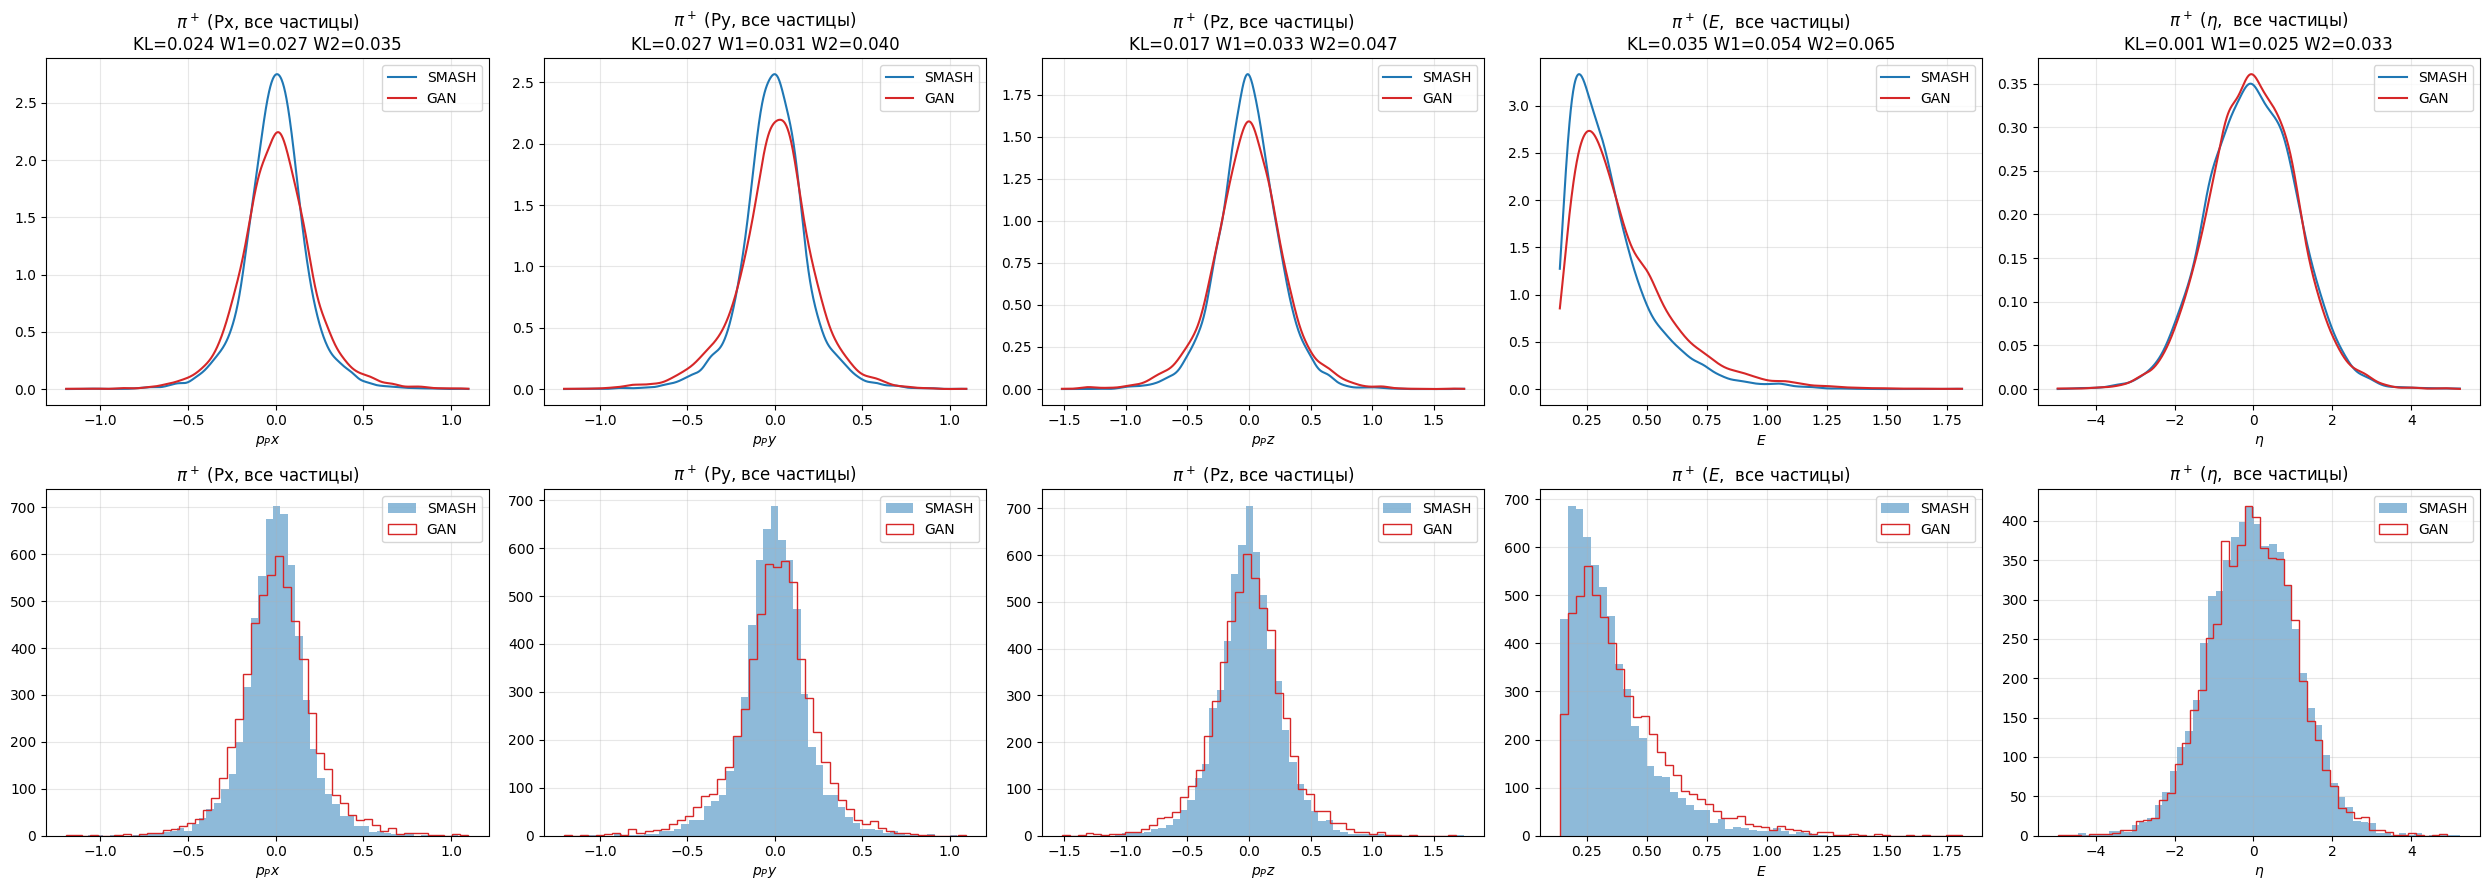

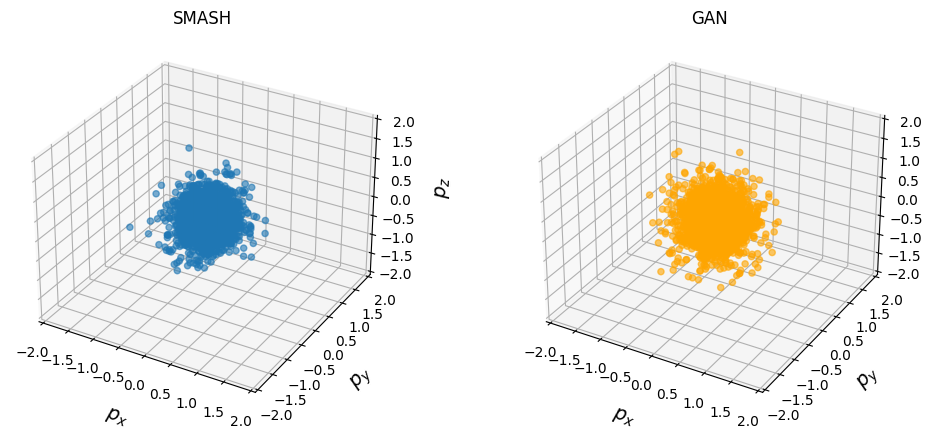

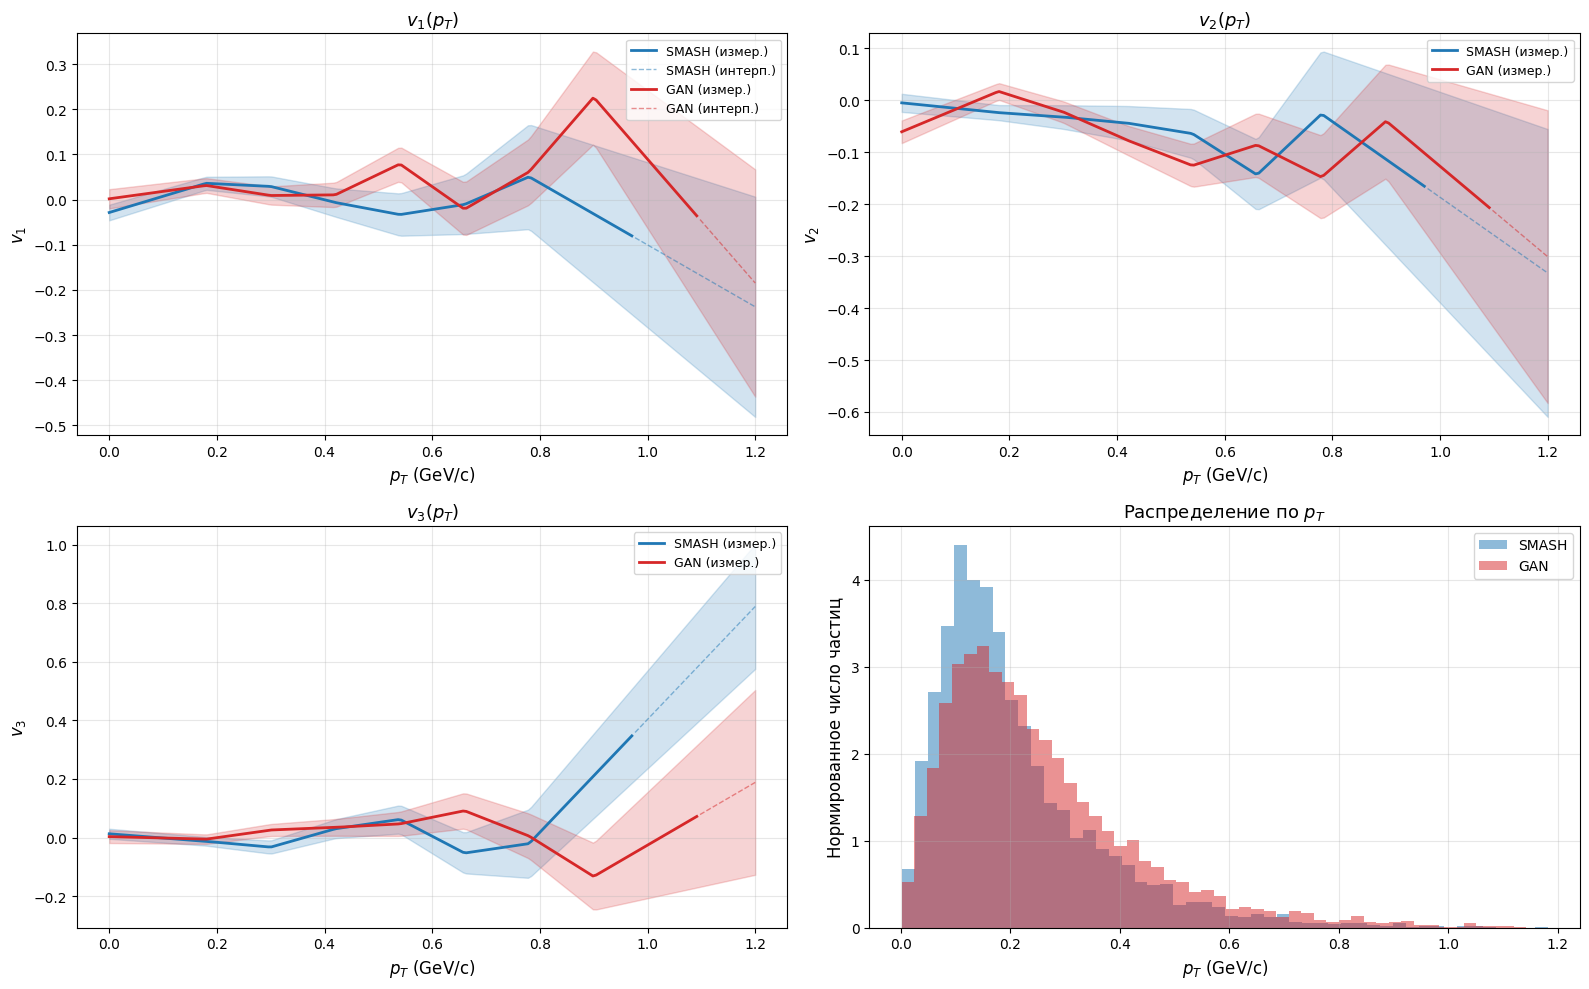

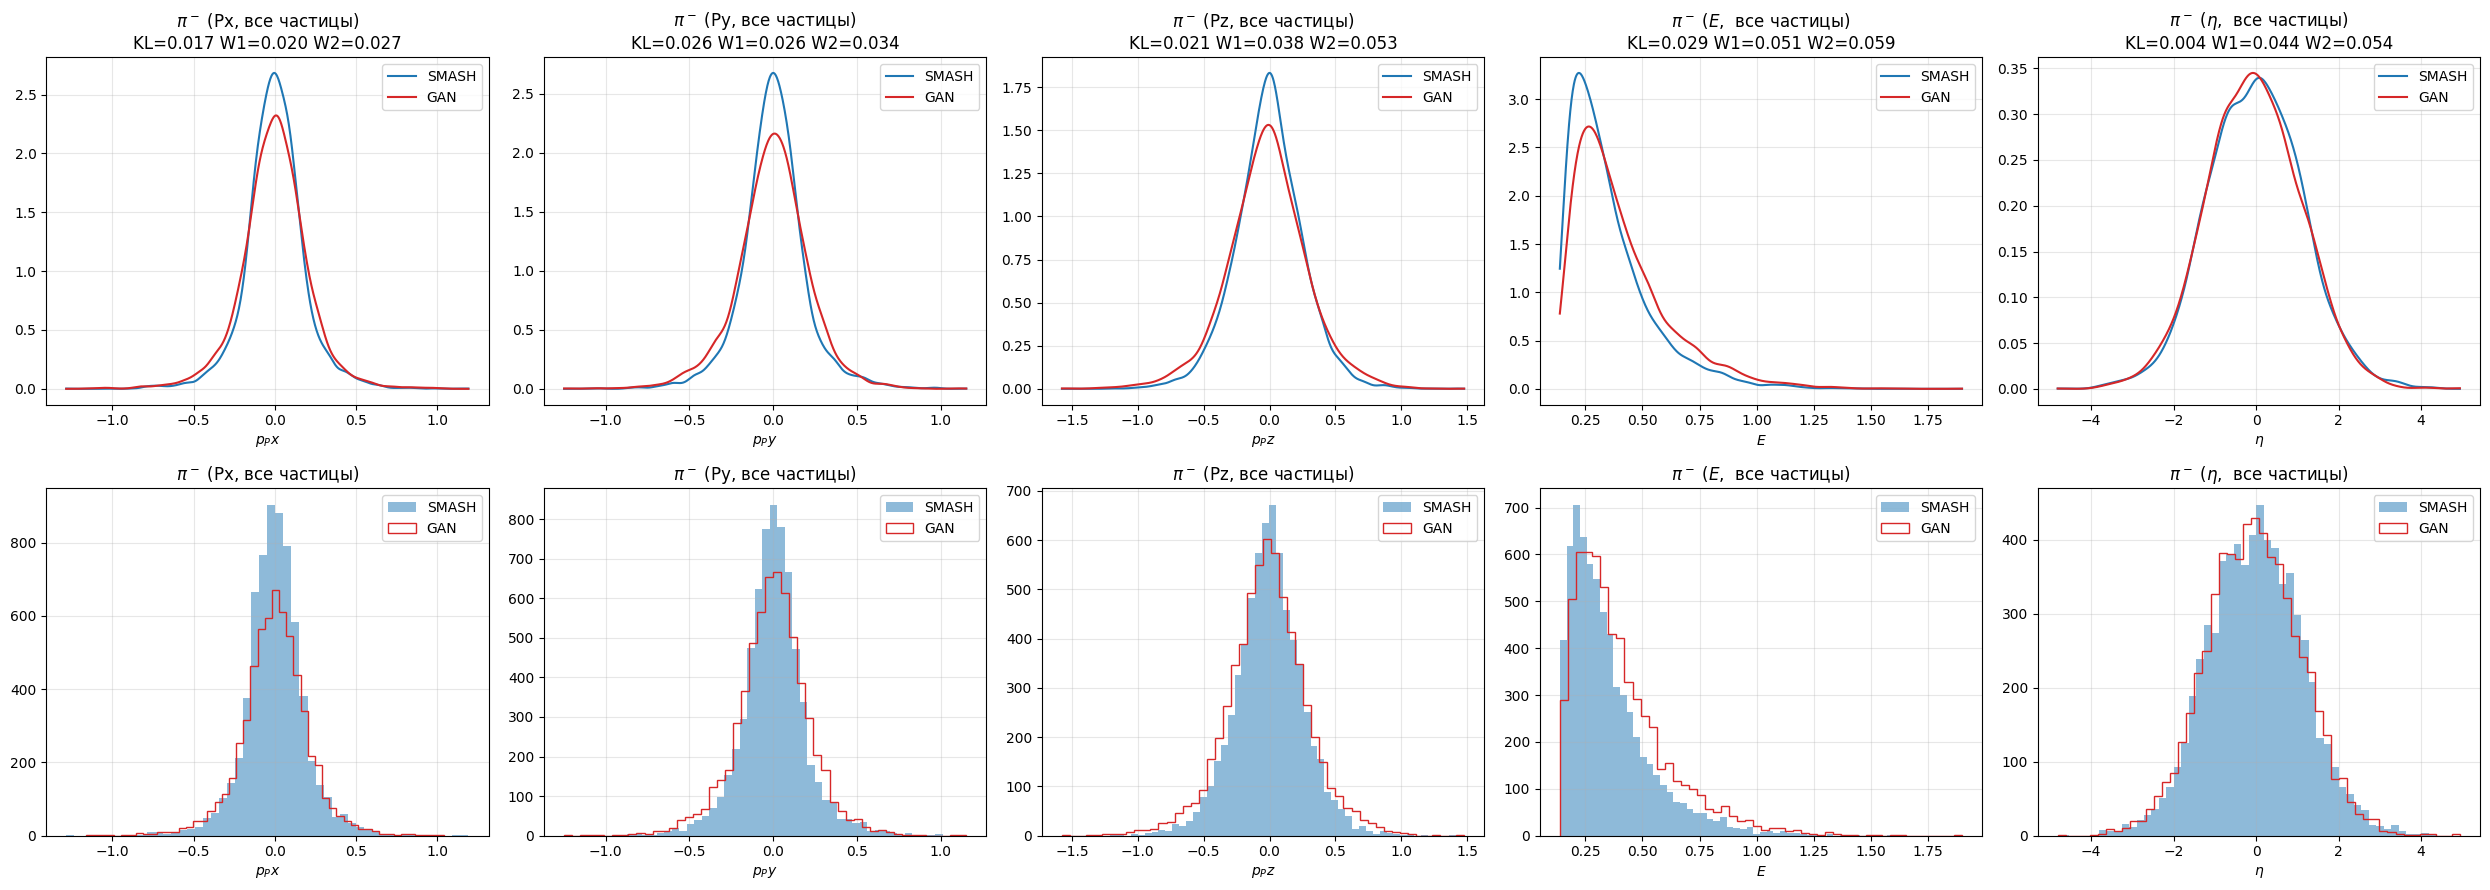

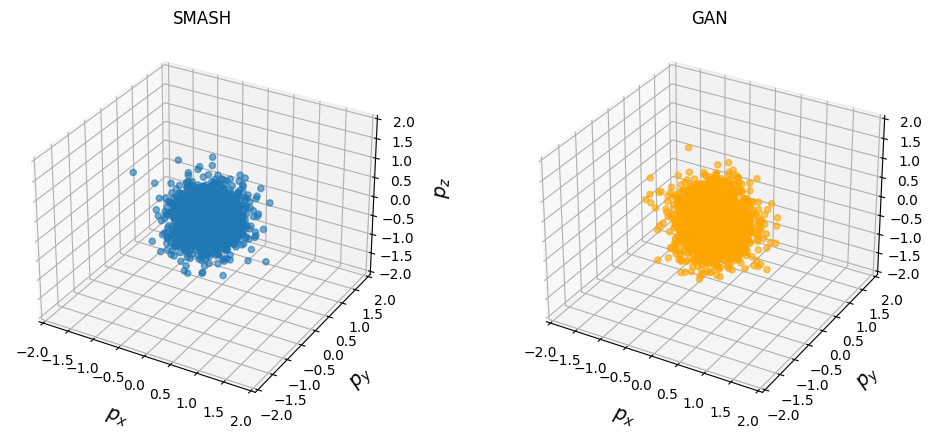

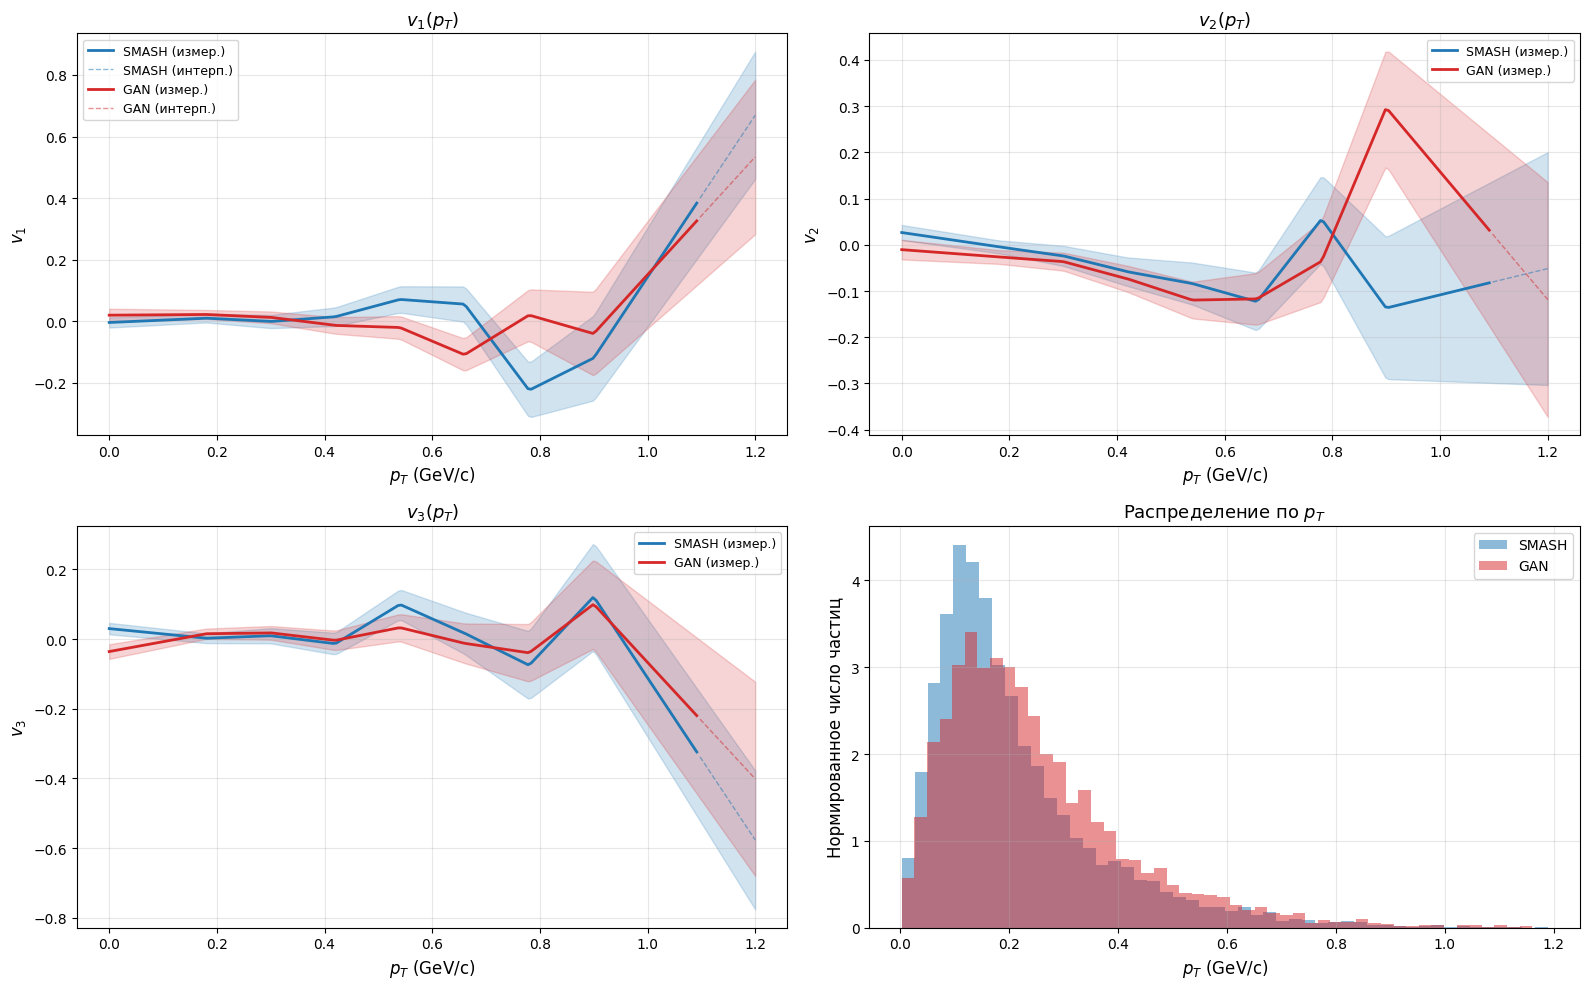

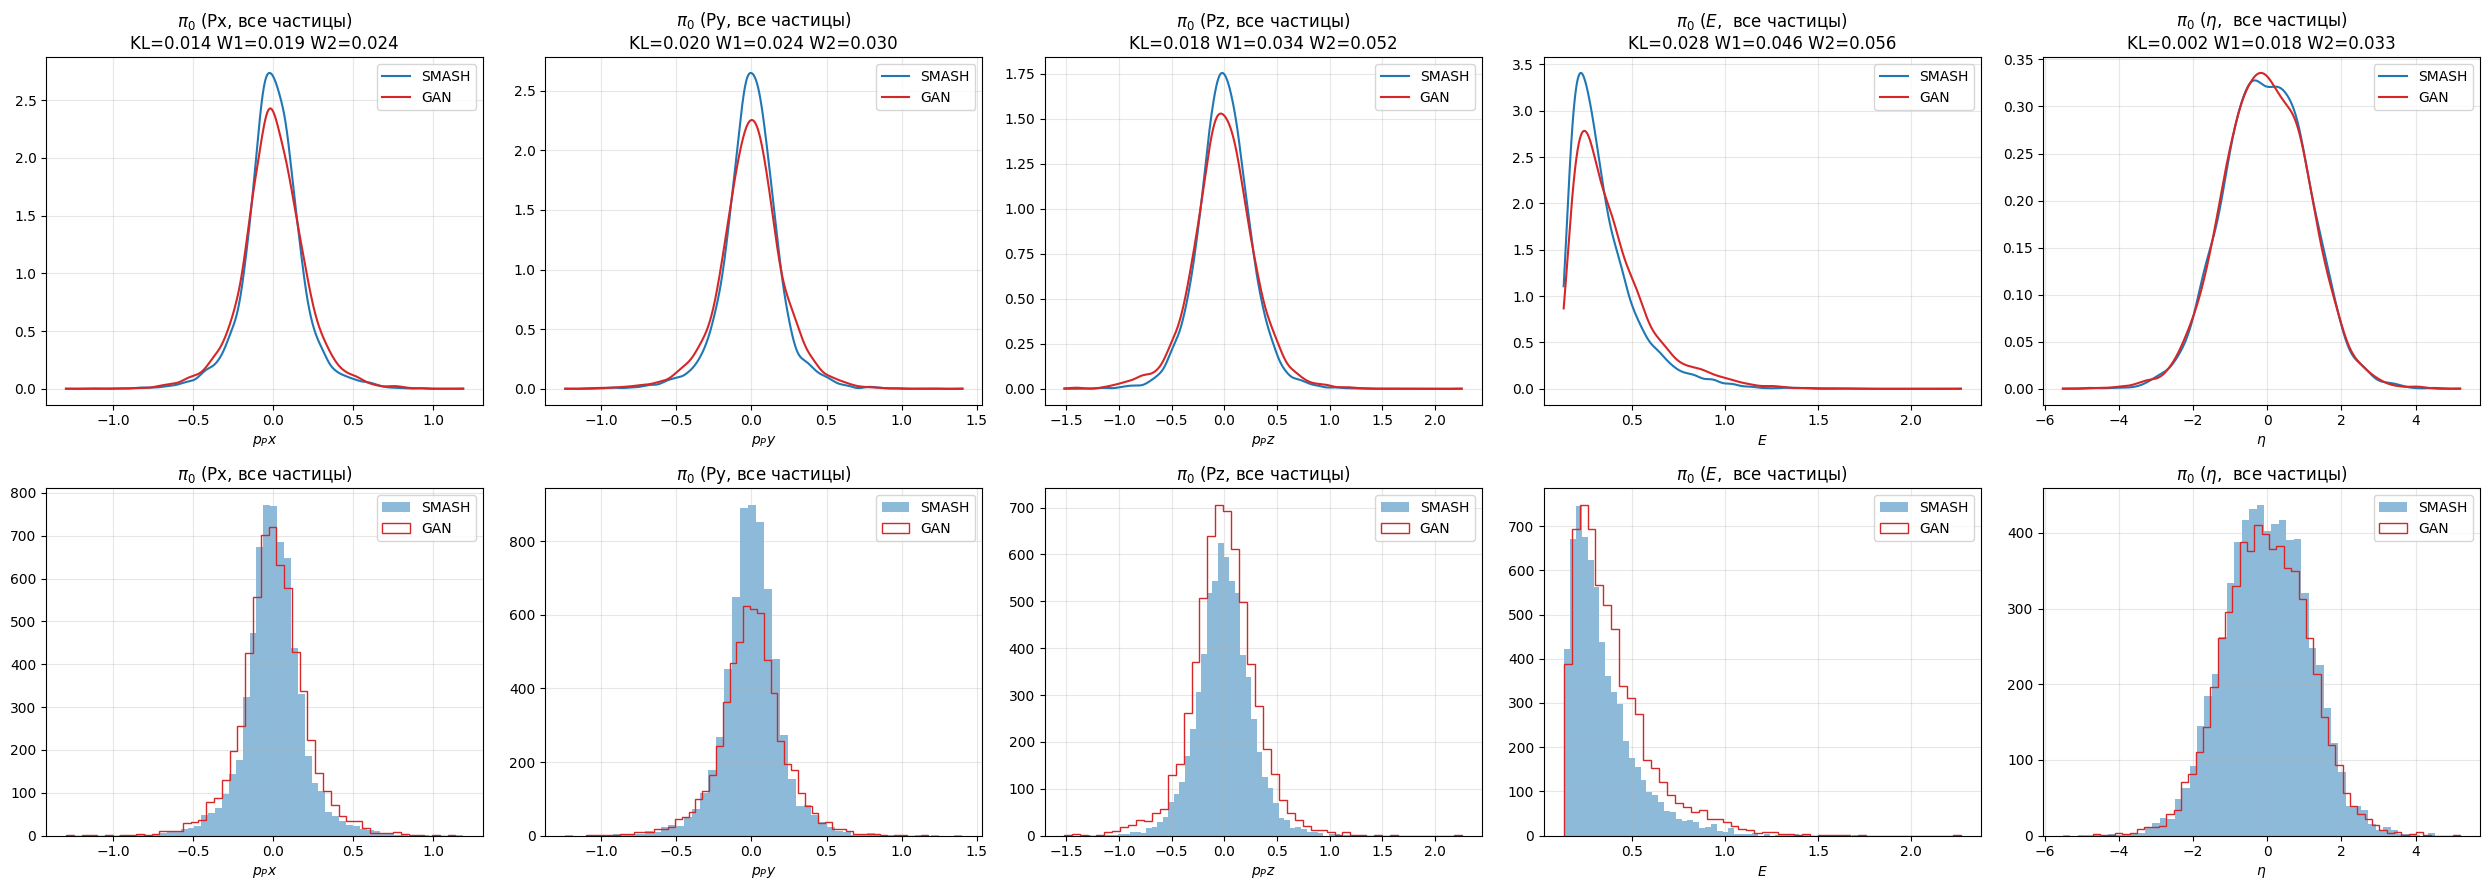

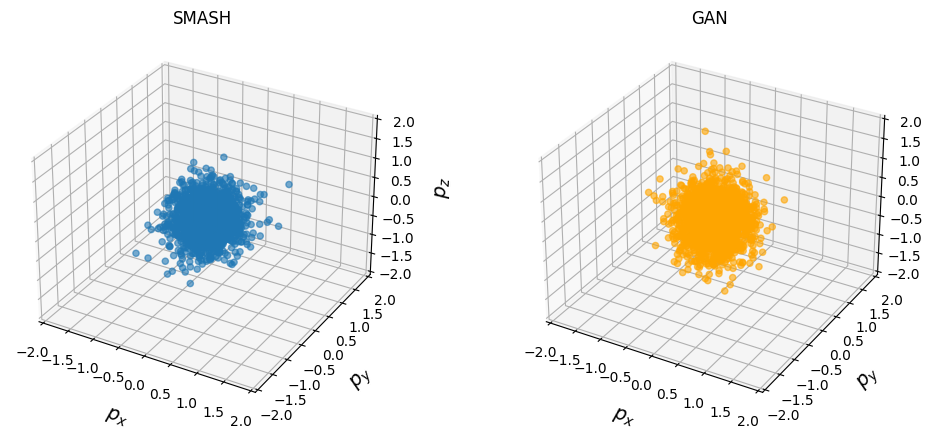

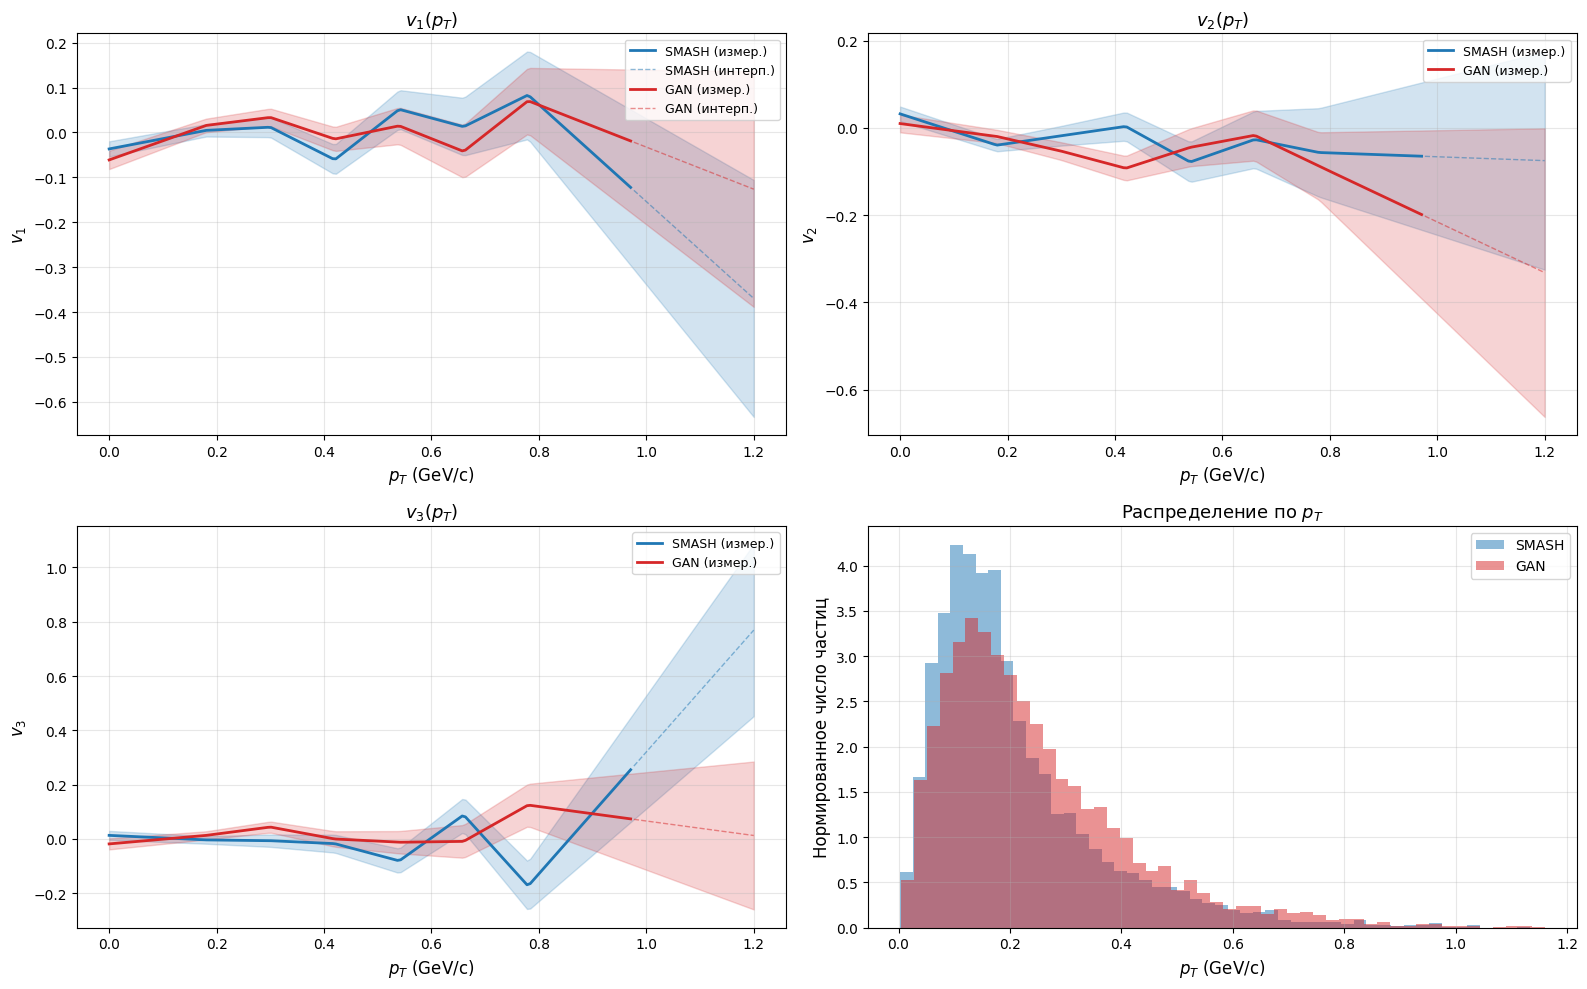

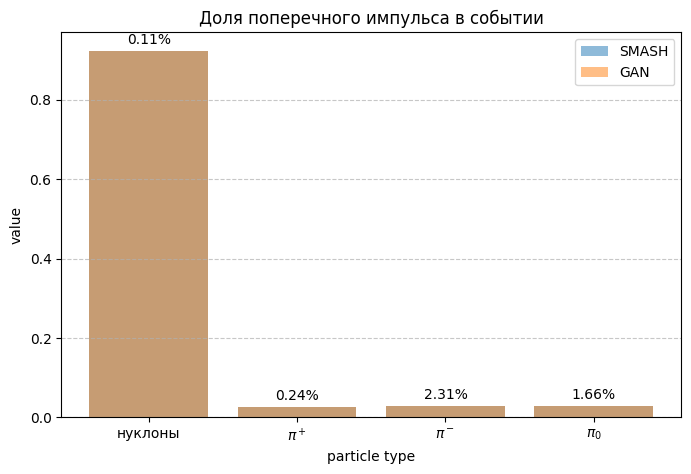

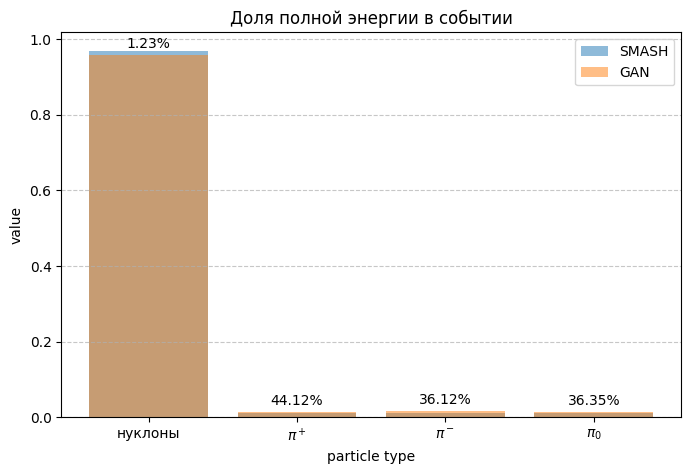

In [20]:
G = Pion_Gan_Generator(
    latent_global=latent_dim,
    latent_local=latent_local_dim,
    num_labels=num_classes,
    feats=feat_dim,
    max_len=meson_max,
    d_model=hid_dim,
    n_heads=n_heads,
    extern_cond_d=extern_cond_d,
    d_ff=hid_dim * 2,
    n_modes=n_modes,
    n_layers=num_layers_gen,
    use_learnable_noise=False,
    use_weight_norm=(not use_shadow),
).to(device)
D = Pion_Gan_Discriminator(
    num_labels=num_classes,
    feats=feat_dim,
    d_model=hid_dim,
    n_heads=n_heads,
    d_ff=hid_dim * 2,
    extern_cond_d=extern_cond_d,
    n_layers=num_layers_disc,
    use_weight_norm=(not use_shadow),
).to(device)

G.load_state_dict(torch.load("_best_urqmd_flow_g.pt", map_location=device))
D.load_state_dict(torch.load("_best_urqmd_flow_d.pt", map_location=device))
G, D = finetune(G, D)
if use_shadow:
    G_shadow = deepcopy(G).eval()
    update_average(G_shadow, G, beta=0.0)
else:
    G_shadow = G

opt_G = torch.optim.Adam(G.parameters(), lr=1e-5, betas=(0.5, 0.9))
opt_D = torch.optim.Adam(D.parameters(), lr=1e-5, betas=(0.5, 0.9))

epochs_finetune = 100
loss_hist_finetune = {"d_loss": [], "g_loss": [], "flow_loss": []}
best_flow_loss_smash = float("inf")

for epoch in range(1, epochs_finetune + 1):
    ep_loss = train_epoch(
        G,
        D,
        smash_train_loader,
        opt_G,
        opt_D,
        device,
        d_iters=1,
        lambda_gp=10,
        lambda_flow=0.05,
        clip_val=1.0,
        use_shadow=use_shadow,
        G_shadow=G_shadow,
        ema_beta=0.999,
    )
    for k, v in ep_loss.items():
        loss_hist_finetune[k].append(v)

    G_shadow.eval()
    val_flow = 0.0
    num_val_batches = 0
    for val_batch in smash_val_loader:
        val_flow += get_flow_metric(G_shadow, val_batch, device)
        num_val_batches += 1
    avg_val_flow = val_flow / num_val_batches if num_val_batches else float("inf")
    G_shadow.train()

    if avg_val_flow < best_flow_loss_smash:
        best_flow_loss_smash = avg_val_flow
        torch.save(G.state_dict(), "_best_smash_ls_flow_g.pt")
        torch.save(D.state_dict(), "_best_smash_ls_flow_d.pt")
        torch.save(G_shadow.state_dict(), "_best_smash_ls_flow_g_shadow.pt")

    if epoch % 10 == 0:
        plot_losses(loss_hist_finetune)
        get_dist_metrics(
            G_shadow,
            generate_transformer,
            meson_max,
            list(smash_val_final["target_moms"].values),
            smash_val_final[cond_cols].values.astype(float),
            smash_val_final["label"].values,
            list(smash_val_final["target_mask"].values),
            device,
        )
        # get_energy_metrics(
        #    G_shadow,
        #    generate_transformer,
        #    meson_max,
        #    list(smash_val_final["target_moms"].values),
        #    list(smash_val_final[nucl_cols[0]].values),
        #    list(smash_val_final[nucl_mask_cols[0]].values),
        #    smash_val_final['event'].values,
        #    smash_val_final[cond_cols].values.astype(float),
        #    smash_val_final["label"].values,
        #    list(smash_val_final["target_mask"].values),
        #    device
        # )

G.load_state_dict(torch.load("_best_smash_ls_flow_g.pt"))
D.load_state_dict(torch.load("_best_smash_ls_flow_d.pt"))

if use_shadow:
    G_shadow.load_state_dict(torch.load("_best_smash_ls_flow_g_shadow.pt"))
else:
    G_shadow = G

clear_output()

METRICS["smash_ls"] = {}
_ = get_metrics(
    G_shadow,
    smash_test_final,
    cond_cols,
    nucl_cols,
    nucl_mask_cols,
    meson_max,
    device,
    final_metrics=METRICS["smash_ls"],
    real_name="SMASH",
)

In [21]:
records = []
for model, pions in METRICS.items():
    for pion, model_metrics in pions.items():
        for metric, value in model_metrics.items():
            records.append(
                {
                    "model": model,
                    "pion": pion,
                    "metric": metric,
                    "value": value,
                }
            )
df_records = pd.DataFrame(records)
res = (
    df_records.groupby(["model", "metric"])["value"].agg(["mean", "std"]).reset_index()
)
res

,model,metric,mean,std
0,smash_ls,e,29.455000,0.000000
1,smash_ls,e_kl,0.030873,0.003851
2,smash_ls,e_kl_0,0.533987,0.089314
3,smash_ls,e_w1,0.050527,0.004246
4,smash_ls,e_w1_0,0.248301,0.023923
5,smash_ls,eta_kl,0.002494,0.001102
6,smash_ls,eta_kl_0,0.013143,0.010550
7,smash_ls,eta_w1,0.029059,0.013230
8,smash_ls,eta_w1_0,0.138291,0.049441
9,smash_ls,pt,1.080000,0.000000


In [22]:
df_records.to_csv("flows_ls.csv")

In [23]:
d = res[res.model.str.contains("smash") & res.metric.str.contains("eta_w1_0")]
d[d["mean"] == d["mean"].min()]

,model,metric,mean,std
8,smash_ls,eta_w1_0,0.138291,0.049441
